# **Trabajo I - Minería de datos**

Trabajo de:


- May Yun Amorós Más

- Jorge Tomás Linares

- Senén Martínez Andreu



## **1. Introducción**
---

En este trabajo de la asignatura de Minería de Datos haremos una revisión de la evolución de las economías europeas y estadounidenses desde 1980. El objetivo es analizar, a partir de los datos, la evolución de distintos sectores económicos, identificando sus periodos de crecimiento y descenso y relacionándolos con el contexto temporal en el que se producen.

Para establecer dicha comparación, utilizaremos los datos de la **FRED** (Federal Reserve Bank of St. Louis) que consultamos mediante la API:

https://fred.stlouisfed.org/docs/api/fred/

Esta API estadounidense es pública y cualquier persona puede obtener el acceso. Además, en dicha API, se incluye información económica relevante de la zona europea.

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from datetime import datetime
from sklearn.impute import KNNImputer

API_KEY = '' # API_KEY borrada, consigue la tuya en la pagina web de FRED.

In [ ]:
# Paquete para hacer predicciones.
!pip install pmdarima

from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.8 MB/s eta 0:00:00


Utilizando la API accederemos a series temporales que mostrarán la evolución de varios indicadores económicos. La manera de realizar las llamadas a la API será a partir de la siguiente definición de clase.


In [ ]:
class FredAPI:
    def __init__(self, api_key):
        self.api_key = api_key
        self.base_url = "https://api.stlouisfed.org/fred"

    def _get(self, endpoint, params=None):
        if params is None:
            params = {}
        params["api_key"] = self.api_key
        params["file_type"] = "json"

        url = f"{self.base_url}/{endpoint}"
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()

    def get_series_info(self, series_id):
        return self._get("series", {"series_id": series_id})

    def get_series_observations(self, series_id, start_date=None, end_date=None, frequency=None,aggregation_method = None):
        params = {"series_id": series_id}

        if start_date:
            params["observation_start"] = start_date
        if end_date:
            params["observation_end"] = end_date
        if frequency:
            params["frequency"] = frequency
        if aggregation_method:
            params["aggregation_method"] = aggregation_method

        return self._get("series/observations", params)


In [ ]:
# Inicializamos la clase
fred = FredAPI(api_key=API_KEY)

### **1.1. Funciones útiles para limpiar los datos**

Las siguientes funciones nos ayudarán a limpiar y filtrar la información de los datos proporcionados. El proceso de obtención y preprocesado inicial de los datos consta de:

1.  Llamada a la API para obtener la serie temporal.
2.  Filtrado de las columnas *date* y *value* que contendrán las fechas de la serie y sus valores correspondientes.
3.  Conversión de la columna *date* a índice.
4.  Al haber "." que representan valores nulos en la serie, los modificamos para que sean de tipo `NaN`.
5.  Asignamos, de momento, el tipo de dato `float` a las variables que compondrán el dataset.
6. Le damos nombre a las columnas.


In [ ]:
def main(nombre, codigo):
  """
  LLamada a la API para la obtención de las series y proceso de limpieza.
  """
  # Obtenemos la información de la API
  json = fred.get_series_observations(codigo)['observations']

  # Convertimos a dataframe
  df = pd.DataFrame(json)

  # Obtenemos las columnas date y value
  df = obtener_columnas_necesarias(df)

  # Ponemos de índice la fecha
  df.index = pd.to_datetime(df['date'])
  df = df.drop(columns=['date'])

  # Limpiamos los valores no numéricos
  df = reemplazar_no_numericos_por_nan(df)

  # Convertimos a float
  df['value'] = df['value'].astype(float)

  # Usamos el nombre legible como nombre de columna
  df = renombrar_columna(df, nombre)

  return df

def reemplazar_no_numericos_por_nan(df, columna = 'value'):
  """
  Convierte una columna a numérica y reemplaza valores no numéricos por NaN.
  """
  df[columna] = pd.to_numeric(df[columna], errors='coerce')
  return df


def obtener_columnas_necesarias(df):
  """
  Esta función se queda únicamente con las columnas que necesitamos.
  En este caso nos quedamos con las columnas date y value.
  """
  columnas_importantes = ['date','value']
  df = df[columnas_importantes]
  return df

def renombrar_columna(df,nombre_columna_nueva):
  """
  df es el dataframe que contiene la columna 'value' a renombrar.
  nombre_columna_nueva es el nuevo nombre de la columna.
  """
  df.rename(columns={'value': nombre_columna_nueva}, inplace=True)
  return df

def insertar_columna(df, nombre_anterior, nombre_columna, columna):
  """
  Insertamos una columna después de la columna llamada 'nombre_anterior'.
  """
  posicion = df.columns.get_loc(nombre_anterior) + 1
  df.insert(posicion, nombre_columna,columna)


### **1.2. Funciones útiles para plotear**

Todas estas funciones se utilizarán para realizar las representaciones gráficas del trabajo.

In [ ]:
def get_recession_periods(series):
    """
    Convierte una serie de 0/1 en lista de intervalos (start, end).
    """
    periods = []
    in_rec = False
    for i, val in enumerate(series):
        if val == 1 and not in_rec:
            start = i
            in_rec = True
        elif val == 0 and in_rec:
            end = i - 1
            periods.append((start, end))
            in_rec = False
    if in_rec:  # si la recesión llega al final de la serie
        periods.append((start, len(series)-1))
    return periods


def shade_recessions(ax, rec_series, color='gray', alpha=0.25, zorder=0):
    """
    Sombrea periodos donde rec_series == 1.

    Args:
        ax          : eje matplotlib
        rec_series  : Serie binaria (0/1 o bool) con índice de fechas
        color       : color de la franja
        alpha       : transparencia
        zorder      : orden de dibujo (negativo = fondo)
    """

    # Asegurar formato correcto (para no tener NaN)
    rec = rec_series.fillna(0).astype(int)

    # Detectar cambios de régimen (0 a 1 y 1 a 0)
    groups = (rec != rec.shift()).cumsum()

    for _, sub in rec.groupby(groups):
        if sub.iloc[0] != 1:
            continue

        start = sub.index[0]
        end   = sub.index[-1]

        ax.axvspan(start, end, color=color, alpha=alpha, zorder=zorder)


def shade_recessions_with_labels(ax, series, labels, color='#c0392b', alpha=0.25):
    periods = get_recession_periods(series)

    for (start_idx, end_idx), label in zip(periods, labels):
        start = series.index[start_idx]
        end = series.index[end_idx]

        # Dibujar zona sombreada
        ax.axvspan(start, end, color=color, alpha=alpha)

        # Calcular posición central en X para etiqueta
        x_center = start + (end - start) / 2

        # Colocar texto VERTICAL centrado
        ax.text(
            x_center, 0.5, label,
            ha='center', va='center',
            fontsize=10,
            color='#5a0000',
            rotation=90,          # VERTICAL
            alpha=0.85,
            transform=ax.get_xaxis_transform(),
        )

def plot_series(df: pd.DataFrame, columns: list[str], ax = None, method = "line"):
    """
    Plotea múltiples columnas de un mismo dataframe con estilo mejorado.

    Args:
        df      : DataFrame con índice de fechas
        columns : lista de nombres de columnas a plotear

    Ejemplo:
        plot_series(df, ['GDP', 'GDP2', 'GDP3'])
    """
    colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c']

    plt.style.use('seaborn-v0_8-whitegrid')

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))
    else:
        fig = ax.figure


    for i, col in enumerate(columns):
        serie = df[col].dropna()
        color = colors[i % len(colors)]
        if method == 'line':
            ax.plot(serie.index, serie, color=color, linewidth=2, label=col)
        if method == 'scatter':
            ax.scatter(serie.index, serie, color=color, linewidth=2, label=col)

    ax.set_xlabel('Year', fontsize=12, labelpad=10)
    ax.set_ylabel(' / '.join(columns), fontsize=12, labelpad=10)

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')

    title = ' vs '.join(columns)
    plt.title(title, fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout()

    return fig,ax

def plot_asimetria_style(dic_region1, dic_region2, nombre_region1='EEUU', nombre_region2='Europa', ax=None):
    """
    Genera un gráfico de barras comparando el coeficiente de asimetría de dos regiones

    Args:
        dic_region1 : dict con variables y coeficiente de asimetría (primera región)
        dic_region2 : dict con variables y coeficiente de asimetría (segunda región)
        nombre_region1 : str, nombre para la primera región
        nombre_region2 : str, nombre para la segunda región
        titulo : str, título del gráfico
        ax : matplotlib.axes.Axes, opcional para plotear sobre un eje existente
    """
    colors = ['#3498db', '#e67e22']  # colores consistentes con plot_series
    plt.style.use('seaborn-v0_8-whitegrid')

    if ax is None:
        fig, ax = plt.subplots(figsize=(14,6))
    else:
        fig = ax.figure

    variables = list(dic_region1.keys())
    n_vars = len(variables)
    width = 0.35
    x = np.arange(n_vars)

    # Barras
    ax.bar(x - width/2, [dic_region1[var] for var in variables], width, label=nombre_region1, color=colors[0])
    ax.bar(x + width/2, [dic_region2[var] for var in variables], width, label=nombre_region2, color=colors[1])

    # Líneas discontinuas en 0.5 y -0.5
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.axhline(-0.5, color='gray', linestyle='--', linewidth=1)

    # Etiquetas y estilo
    ax.set_xticks(x)
    ax.set_xticklabels(variables, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Coeficiente de asimetría', fontsize=12)
    ax.set_title('Coeficientes de asimetría: EEUU vs Europa', fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    return fig, ax

def plot_boxplots(df: pd.DataFrame, columns: list[str], ax=None):
    """
    Dibuja boxplots de múltiples columnas de un mismo dataframe.

    Args:
        df      : DataFrame con las variables
        columns : lista de nombres de columnas a representar

    Ejemplo:
        plot_boxplots(df, ['GDP', 'INFLATION', 'INTEREST_RATES'])
    """

    colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c']

    plt.style.use('seaborn-v0_8-whitegrid')

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    else:
        fig = ax.figure

    data = [df[col].dropna() for col in columns]

    box = ax.boxplot(
        data,
        patch_artist=True,
        labels=columns,
        showfliers=True,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(linewidth=1.2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_ylabel('Valores', fontsize=12, labelpad=10)

    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=10)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )

    title = ' vs '.join(columns)
    plt.title(title, fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout()

    return fig, ax

def plot_heatmap(df, title):
    """
    Grafica un heatmap a partir de un DataFrame.

    Args:
        df : DataFrame con los datos a representar en el heatmap
    """

    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(figsize=(14, 8))

    sns.heatmap(
        df,
        cmap="coolwarm",
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        ax=ax
    )

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    plt.tight_layout()
    plt.show()

def plot_imputaciones(df_input, df, methods=["KNN", "Lineal"]):
    """
    Plotea la serie observada frente a distintas imputaciones

    Args:
        df_input : DataFrame con las series imputadas por método
        df       : DataFrame con la serie original
        methods  : lista de métodos de imputación a graficar
    """

    colors = ['#e67e22', '#3498db']
    serie_name = df.columns[0]

    plt.style.use('seaborn-v0_8-whitegrid')

    for method in methods:

        fig, ax = plt.subplots(figsize=(14, 6))

        # Serie imputada
        ax.scatter(
            df_input[method].index,
            df_input[method][serie_name],
            color=colors[0],
            s=40,
            label="Imputación"
        )

        # Serie original
        ax.scatter(
            df.index,
            df[serie_name],
            color=colors[1],
            s=40,
            label="Serie original"
        )

        ax.set_xlabel('Year', fontsize=12, labelpad=10)
        ax.set_ylabel(serie_name, fontsize=12, labelpad=10)

        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.xticks(rotation=45, fontsize=10)
        plt.yticks(fontsize=10)

        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
        )

        ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')

        plt.title(f"Método de imputación: {method}",
                  fontsize=16,
                  fontweight='bold',
                  pad=15)

        plt.tight_layout()
        plt.show()

def plot_agregacion(serie_original, serie_agregada):
    """
    Gráfica la serie original como lineplot y la serie agregada como scatterplot.

    Args:
        serie_original : DataFrame con la serie original
        serie_agregada : DataFrame con la serie agregada
    """

    colors = ['#3498db', '#e67e22']

    plt.style.use('seaborn-v0_8-whitegrid')

    if hasattr(serie_original, "columns"):
        serie_name = serie_original.columns[0]
        y_original = serie_original[serie_name]
    else:
        serie_name = serie_original.name
        y_original = serie_original

    if hasattr(serie_agregada, "columns"):
        y_agregada = serie_agregada[serie_name]
    else:
        y_agregada = serie_agregada

    fig, ax = plt.subplots(figsize=(14, 6))

    # Serie original (línea detrás)
    ax.plot(
        y_original.index,
        y_original,
        color=colors[0],
        linewidth=2.5,
        label="Serie original",
        zorder=1
    )

    # Serie agregada (puntos delante)
    ax.scatter(
        y_agregada.index,
        y_agregada,
        color=colors[1],
        s=15,              # puntos más pequeños
        label="Agregación mensual",
        zorder=3           # delante de la línea
    )

    ax.set_xlabel('Year', fontsize=12, labelpad=10)
    ax.set_ylabel(serie_name, fontsize=12, labelpad=10)

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:,.2f}')
    )

    ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')

    plt.title(
        'Agregación mensual - ' + serie_name,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    plt.tight_layout()
    plt.show()

## **2. Preprocesamiento del conjunto de datos**
---


Las economías de Estados Unidos y de Europa tienen diferentes indicadores que nos muestran cómo está yendo su economía en varios sectores. Estos sectores que vamos a comparar se muestran a continuación:

| Categoría | Código | Frecuencia | Descripción | Unidades |
|:------:|:-------|:-----|:-----|:------|
|GDP| *GDPC1* | Trimestral | GDP (PIB) Real de EEUU | Billions of Chained 2017 Dollars |
| GDP | *CLVMNACNSAB1GQEU272020* | Trimestral | GDP (PIB) Real de 27 países de Europa | Millions of Chained 2010 Euros |
|Inflación| *CPIAUCSL* | Mensual | Índice de precios al consumidor para todos los consumidores urbanos en EEUU  | Índice 1982-1984=100 |
| Inflación | *FPCPITOTLZGEUU* | Anual | Inflación y precios al consumidor en la Unión Europea | Por ciento |
|Tipo de Interés| *FEDFUNDS* | Mensual | Tasa Efectiva de Fondos Federales de EEUU (tipo de interés promedio ponderado al que los bancos comerciales de EEUU se prestan dinero entre sí a un día (overnight) sin garantía) | Por ciento |
| Tipos de interés | *IRLTLT01EZQ156N* | Trimestral | Tipos de interés de Europa: Rendimientos de los bonos gubernamentales a largo plazo: 10 años | Por ciento |
|Producción Industrial| *IPB50001NQ* | Trimestral | Producción industrial de EEUU: Índice total  | Índice 2017=100 |
| Producción industrial | *PRINTO01EZQ661N* | Trimestral | Producción industrial de Europa excluyendo la construcción | Índice 2015=100 |
|Vivienda| *USSTHPI* | Trimestral | Índice de precios de la vivienda de todas las transacciones en EEUU  | Índice 1980:Q1=100 |
| Vivienda | *QXMN628BIS* | Trimestral | Índice de precios de las propiedades residenciales en Europa | Índice 2010=100 |
|Empleo| *LREM64TTUSQ156N* | Mensual | Ratio de población empleada de 15 a 64 años en EEUU| Por ciento |
| Empleo | *LREM64TTEUQ156N* | Trimestral | Ratio de población empleada de 15 a 64 años en Europa| Por ciento |
|Deuda| *GFDEGDQ188S* | Trimestral | Deuda pública total de EEUU | Por ciento de GDP |
| Deuda | *GCDODTOTLGDZSEMU* | Anual | Deuda del gobierno central total de Europa | Por ciento de GDP |
|Importaciones| *NA000342Q* | Trimestral | Importaciones de bienes y servicios de EEUU | Millones de dólares |
| Importaciones | *XTIMVA01EZQ664N* | Trimestral | Comercio internacional: Importaciones: Valor (bienes): Total para la zona europea | Euros|
|Exportaciones| *NA000352Q* | Trimestral | Exportaciones de bienes y servicios de EEUU  | Millones de dólares |
| Exportaciones | *XTEXVA01EZQ664N* | Trimestral | Comercio internacional: Exportaciones: Valor (bienes): Total para la zona europea | Euros|
|Recesión| *USREC* | Mensual | Indicador de recesión para EEUU | 1 o 0 . Indica si hay una recesión |
| Recesión | *EUROREC* | Mensual | Indicador de recesión para Europa | 1 o 0. Indica si hay una recesión|
| Cambio Dólar-Euro | *EXUSEU* | Mensual | Precio de un euro en dólares | Dólares por euro|

Como se puede ver en la tabla anterior, la frecuencia de las series no es la misma. Esto úlitmo puede suponer una dificultad a la hora de unificar todas las series en una única tabla. Por ello, dado que la mayoría de las series son trimestrales, optaremos por asignar esta frecuencia a las series anuales y mensuales.

A continuación, crearemos un diccionario para cada tipo de frecuencia donde la clave será el nombre de la variable y el valor será el código que identifica cada serie temporal.

### **2.1. Variables trimestrales**

Las series trimestrales se obtendrán directamente desde la API sin realizar ningún tipo de modificación en la frecuencia.

Todas las variables se guardarán en el dataframe `df_TODO`.

In [ ]:
# Organizamos por nombre común como clave y clave para la api como valor.
# Todo esto es para identificar el nombre común con el código que es difícil de reconocer

dict_codigos = {

    # GDP-REAL
    'GDPREAL_EEUU': 'GDPC1',
    'GDPREAL_EURO': 'CLVMNACSCAB1GQEU272020',

    # Tipos de interés Estadounidense
    'INTEREST_RATES_EURO': 'IRLTLT01EZQ156N',

    # Producción industrial
    'INDUSTRIAL_PRODUCTION_EEUU': 'IPB50001NQ',
    'INDUSTRIAL_PRODUCTION_EURO': 'PRINTO01EZQ661N',

    # Vivienda
    'HOUSING_PRICE_INDEX_EEUU': 'USSTHPI',
    'HOUSING_PRICE_INDEX_EURO': 'QXMN628BIS',

    # Deuda estadounidense
    'DEBT_AS_PERCENT_GDP_EEUU': 'GFDEGDQ188S',

    # Empleo europeo
    'EMPLOYMENT_EURO': 'LREM64TTEUQ156N', # 'LFEMTTTTEZQ647N',

    # Importaciones - Exportaciones
    'IMPORTS_EEUU': 'NA000342Q',
    'IMPORTS_EURO': 'XTIMVA01EZQ664N',

    'EXPORTS_EEUU': 'NA000352Q',
    'EXPORTS_EURO': 'XTEXVA01EZQ664N',

}

In [ ]:
df_TODO = pd.DataFrame()

for nombre, codigo in dict_codigos.items():

  df = main(nombre, codigo)
  df_TODO = pd.concat([df_TODO, df], axis=1)

df_TODO = df_TODO[df_TODO.index >= "1980-01-01"]

### **2.2. Variables anuales a trimestrales**

Al pasar las variables de frecuencia anual a trimestral, vemos que se generan valores nulos en los trimestres Q2, Q3 y Q4. Para imputar los valores nulos, aplicaremos la interpolación lineal y KNN con k = 5. Nos quedaremos con el método que se ajuste mejor en cada serie.

In [ ]:
dict_codigos_anual = {
    # Inflación Europea
    'INFLATION_EURO': 'FPCPITOTLZGEUU',

    # Deuda europea
    'DEBT_AS_PERCENT_GDP_EURO' : 'GCDODTOTLGDZSEMU',
}

# Guardamos los nombres de las variables
keys_anual = list(dict_codigos_anual.keys())

In [ ]:
def Imputacion_anual(df, k = 5):
  '''
  Imputación de valores nulos en series anuales a trimestrales.
  '''

  # Generamos rango de fechas trimestrales
  start_date = min(df.index)
  end_date = max(df.index)
  quarterly_dates = pd.date_range(start=start_date, end=end_date, freq='QS')
  pd_quarterly_dates = pd.DataFrame({'date': quarterly_dates})

  # Join rango de fechas con variable anual
  join = pd.merge(pd_quarterly_dates, df, how = "left", left_on="date", right_index=True)
  join.index = join["date"]
  df_anual = join.drop(columns=["date"])
  column_name = df_anual.columns[0]

  # Copias df_anual
  df_copy_KNN = df_anual.copy()
  df_copy_linear = df_anual.copy()
  df_copy_ffill = df_anual.copy()

  # Imputación KNN
  imputerKNN = KNNImputer(n_neighbors=k, weights="distance")
  df_copy_KNN["year"] = df_copy_KNN.index.year
  df_copy_KNN["quarter"] = df_copy_KNN.index.quarter
  df_copy_KNN[column_name] = imputerKNN.fit_transform(df_copy_KNN)

  # Imputación Interpolación Lineal
  df_copy_linear = df_copy_linear.interpolate(method='time', limit_direction='both')

  # Almacenamiento de las opciones de imputación
  input_null = {"KNN": df_copy_KNN,
                "Lineal": df_copy_linear}

  return input_null

**INFLATION_EURO**

In [ ]:
# Datos de la serie INFLATION_EURO
df_inflation_EURO = main(keys_anual[0], dict_codigos_anual[keys_anual[0]])

# Aplicación de los métodos de imputación
df_input_inflation = Imputacion_anual(df_inflation_EURO)

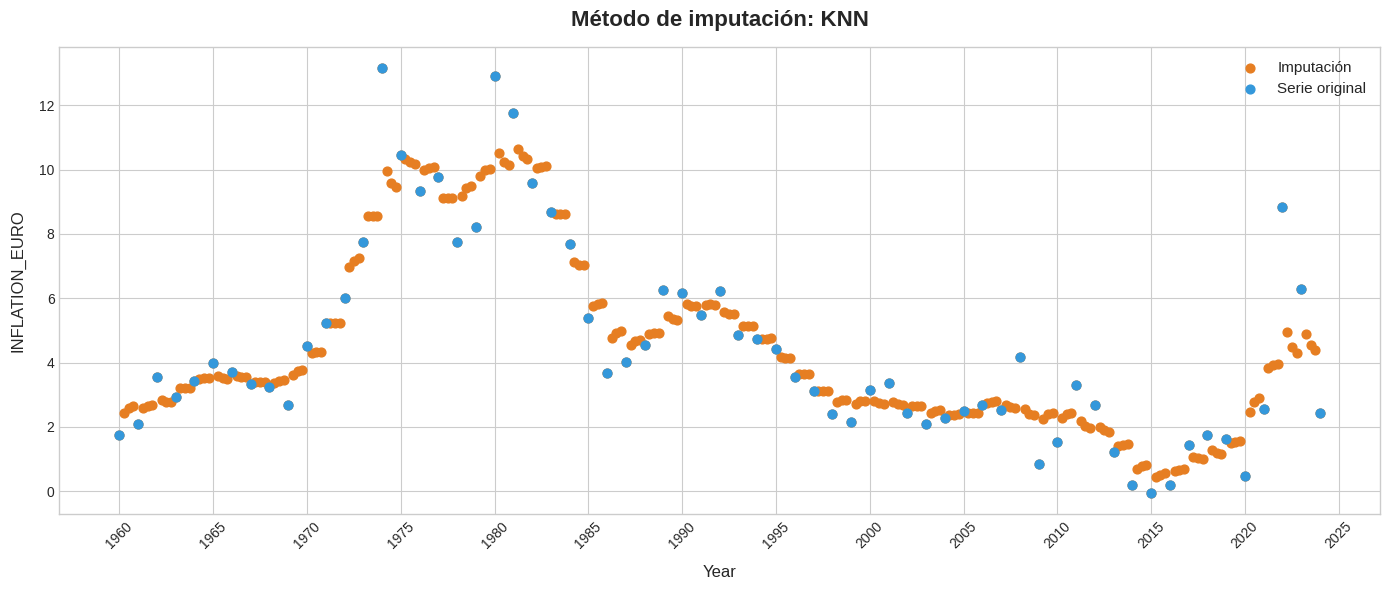

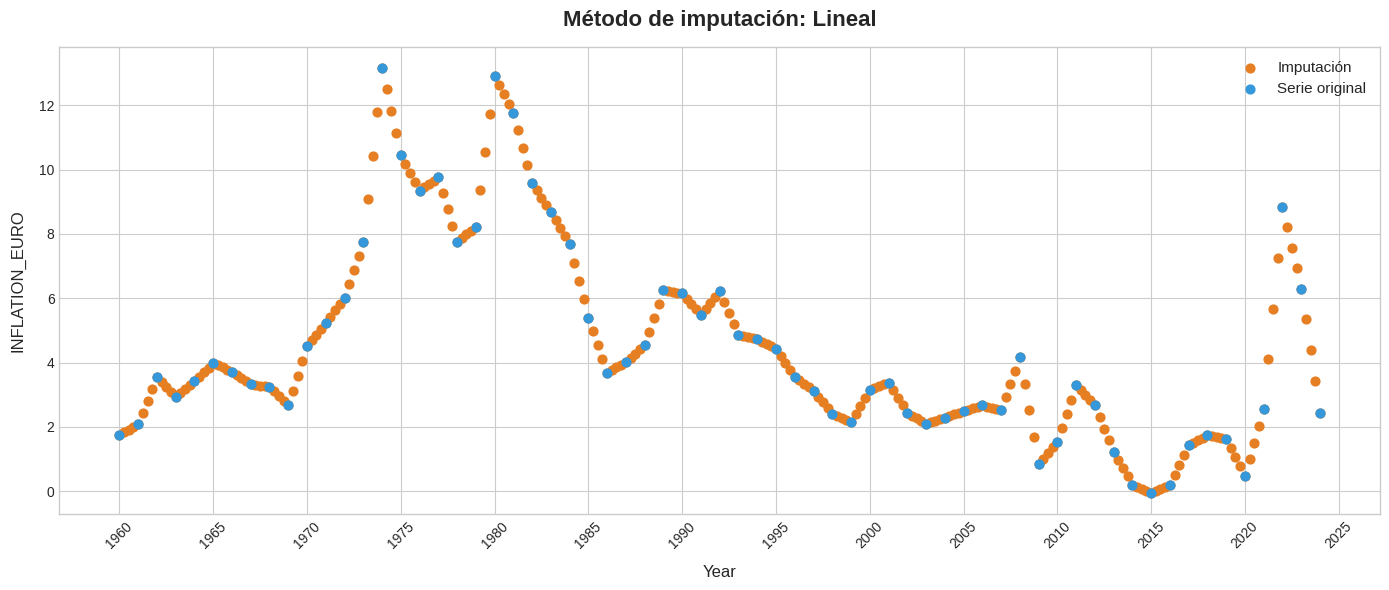

In [ ]:
plot_imputaciones(df_input_inflation, df_inflation_EURO, ["KNN", "Lineal"])

Viendo que la interpolación lineal se ajusta perfectamente a la tendencia que sigue la serie, esta será la opción escogida para la imputación de valores nulos. Insertaremos la columna INFLATION_EURO después de INTEREST_RATES_EURO.

In [ ]:
insertar_columna(df_TODO, "INTEREST_RATES_EURO", df_input_inflation["Lineal"].columns[0], df_input_inflation["Lineal"])

In [ ]:
df_TODO['INTEREST_RATES_EURO']

,INTEREST_RATES_EURO
date,
1980-01-01,12.090847
1980-04-01,12.314000
1980-07-01,12.247143
1980-10-01,12.836647
1981-01-01,13.362013
...,...
2024-10-01,2.869136
2025-01-01,3.130128
2025-04-01,3.084325


**DEBT_AS_PERCENT_GDP_EURO**

In [ ]:
# Datos de la serie DEBT_AS_PERCENT_GDP_EURO
df_debt_EURO = main(keys_anual[1], dict_codigos_anual[keys_anual[1]])

# Aplicación de los métodos de imputación
df_input_debt = Imputacion_anual(df_debt_EURO)

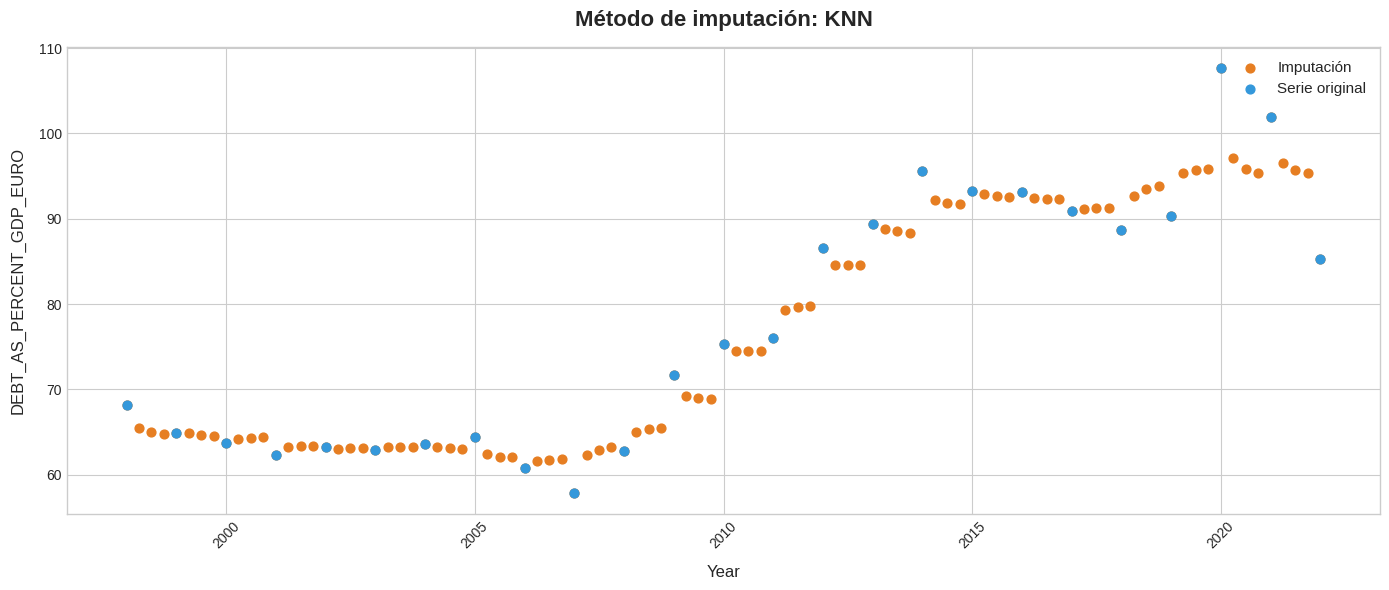

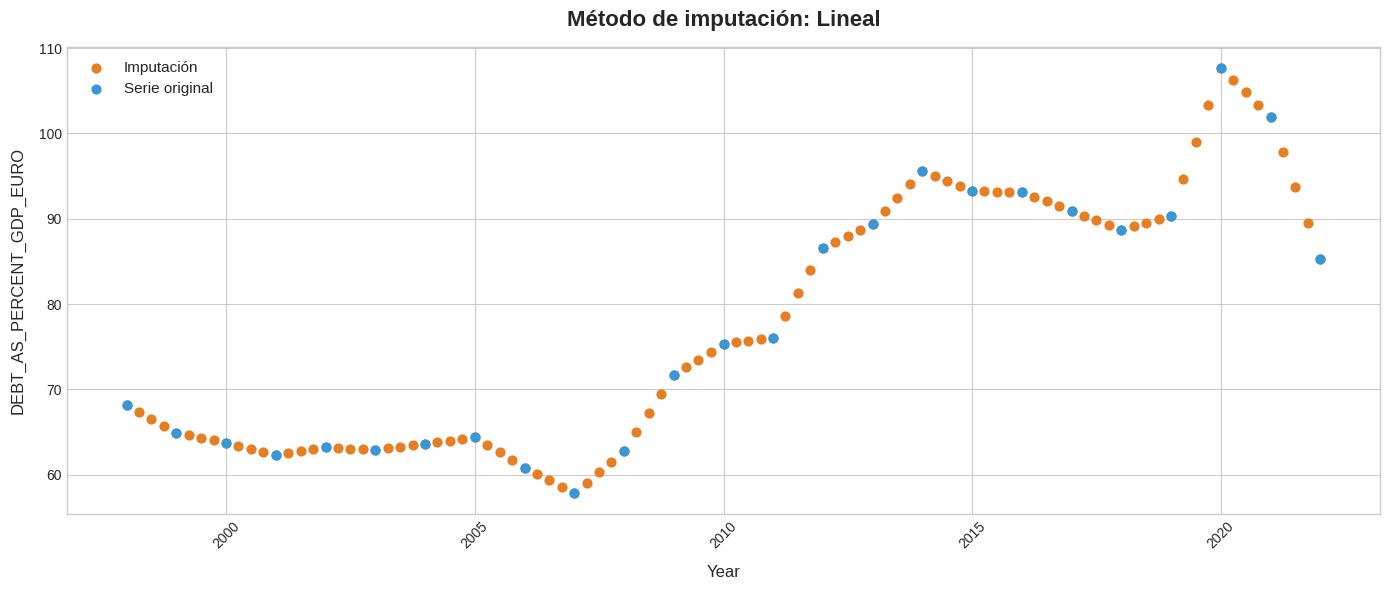

In [ ]:
plot_imputaciones(df_input_debt, df_debt_EURO)

Viendo que la interpolación lineal se ajusta perfectamente a la tendencia que sigue la serie, esta será la opción escogida para la imputación de valores nulos. Insertaremos la columna DEBT_AS_PERCENT_GDP_EURO después de DEBT_AS_PERCENT_GDP_EEUU.

In [ ]:
insertar_columna(df_TODO, "DEBT_AS_PERCENT_GDP_EEUU",df_input_debt["Lineal"].columns[0], df_input_debt["Lineal"])

In [ ]:
df_TODO['DEBT_AS_PERCENT_GDP_EEUU']

,DEBT_AS_PERCENT_GDP_EEUU
date,
1980-01-01,30.94982
1980-04-01,31.37303
1980-07-01,31.77687
1980-10-01,31.15700
1981-01-01,30.87284
...,...
2024-10-01,121.43633
2025-01-01,120.54515
2025-04-01,118.78171


### **2.3. Variables mensuales a trimestrales**

Para pasar las variables mensuales a trimestrales, deberemos de aplicar algún tipo de agregación por trimestres. En general, elegiremos:

*  **Media** del trimestre para variables continuas.
*  **Valor máximo** para variables booleanas (RECESION).

Visualizaremos algunas de las series con sus agregaciones para comprobar que la agregación se ajusta a la serie original.

In [ ]:
dict_codigos_mensual = {

    # Inflación estadounidense
    'INFLATION_EEUU': 'CPIAUCSL',

    # Tipos de interés estadounidense
    'INTEREST_RATES_EEUU': 'FEDFUNDS',

    # Empleo estadounidense
    'EMPLOYMENT_EEUU': 'LREM64TTUSQ156N',

    # Recesión
    'RECESION_EEUU': 'USREC',
    'RECESION_EURO': 'EUROREC',

    # Cambio Dolar-Euro:
    'EXCHANGE_EURO_DOLLAR': 'EXUSEU',
}

keys_mensual = list(dict_codigos_mensual.keys())

col_despues = ['INTEREST_RATES_EURO', 'GDPREAL_EURO', 'DEBT_AS_PERCENT_GDP_EURO', 'EXPORTS_EURO', 'RECESION_EEUU', 'RECESION_EURO']

In [ ]:
def Imputacion_mensual(df, method):
  '''
  Agrupa series mensuales a trimestrales.
  '''

  if method == "mean":
    df_mensual_input = df.resample("QS").mean()
  if method == "max":
    df_mensual_input = df.resample("QS").max()

  return df_mensual_input

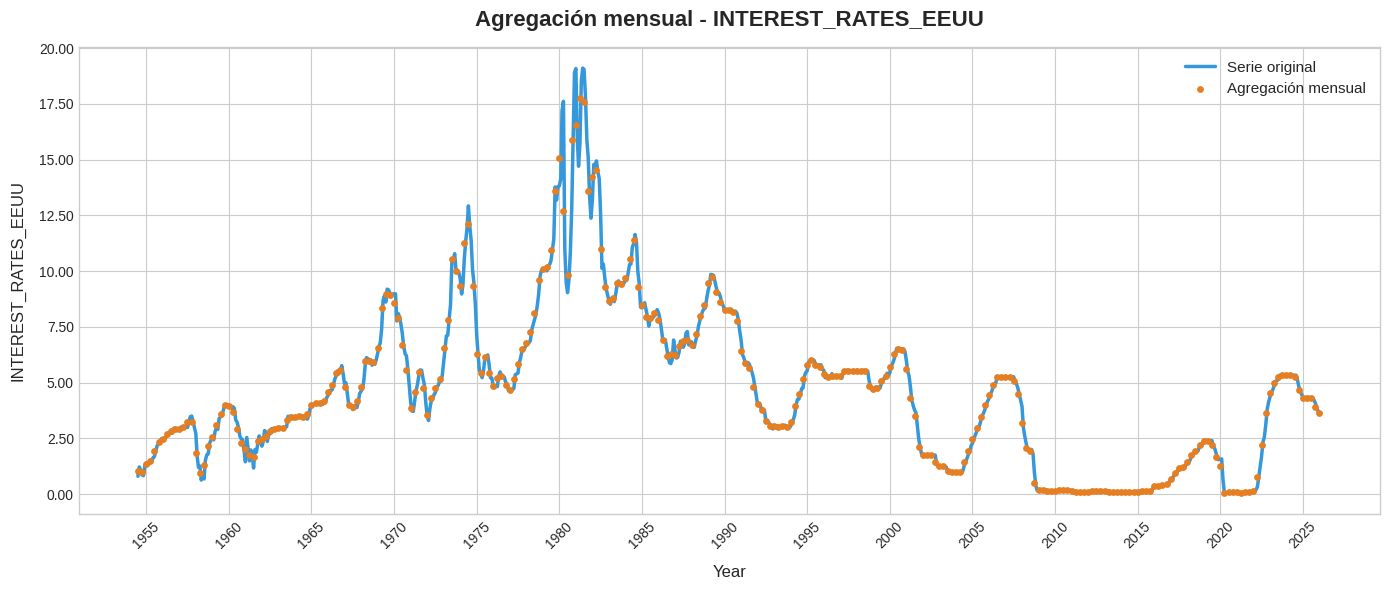

In [ ]:
df_interest_rates_eeuu = main(keys_mensual[1], dict_codigos_mensual[keys_mensual[1]])
df_mensual_interest_rates_eeuu = Imputacion_mensual(df_interest_rates_eeuu, "mean")
plot_agregacion(df_interest_rates_eeuu, df_mensual_interest_rates_eeuu)

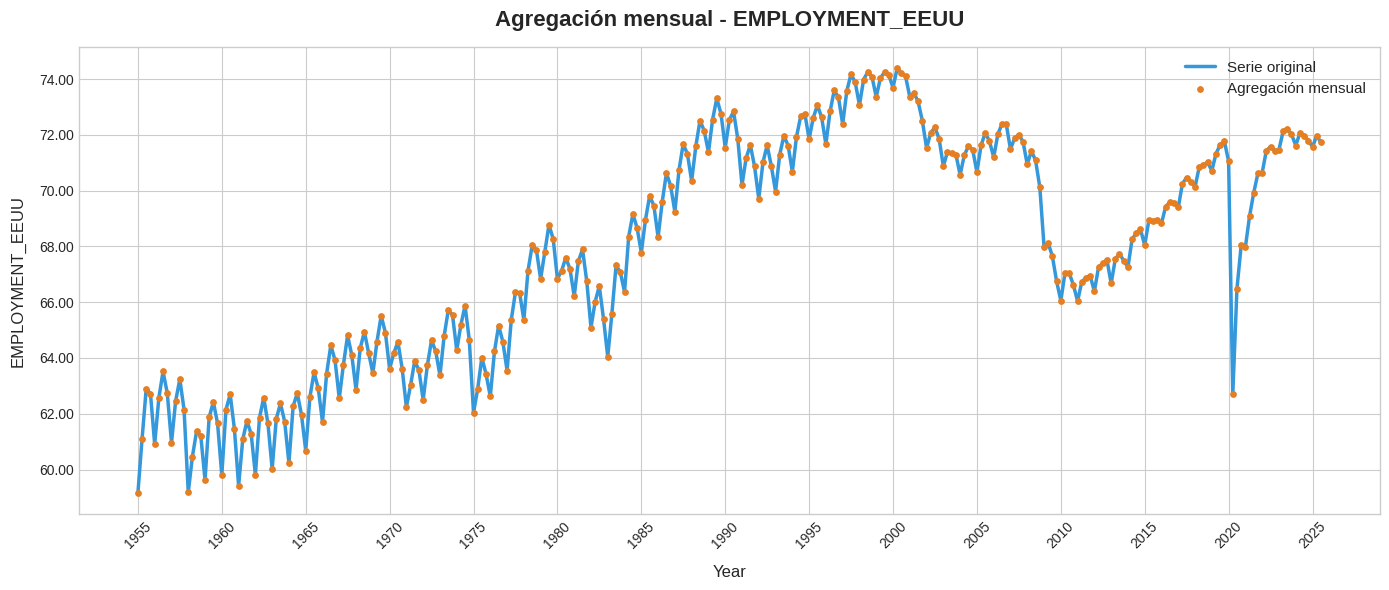

In [ ]:
df_employment_eeuu = main(keys_mensual[2], dict_codigos_mensual[keys_mensual[2]])
df_mensual_employment_eeuu = Imputacion_mensual(df_employment_eeuu, "mean")
plot_agregacion(df_employment_eeuu, df_mensual_employment_eeuu)

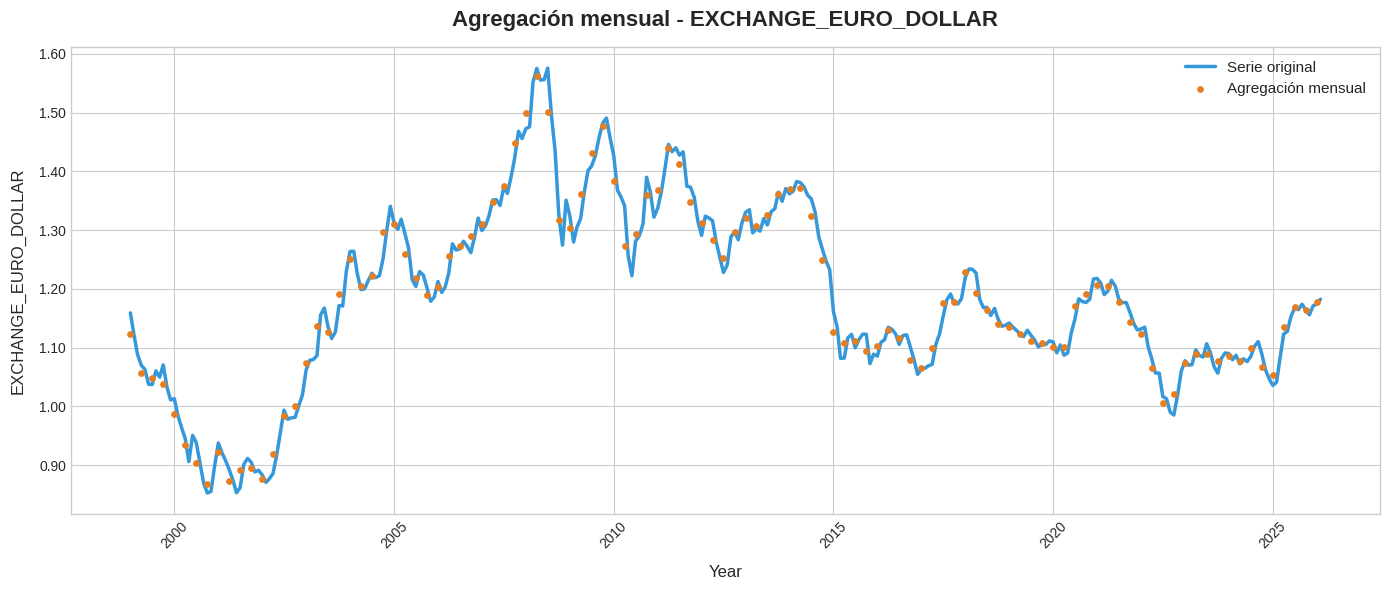

In [ ]:
df_exchange = main(keys_mensual[5], dict_codigos_mensual[keys_mensual[5]])
df_mensual_exchange = Imputacion_mensual(df_exchange, "mean")
plot_agregacion(df_exchange, df_mensual_exchange)

In [ ]:
for i in range(len(dict_codigos_mensual)):
  df_mensual = main(keys_mensual[i], dict_codigos_mensual[keys_mensual[i]])

  if i in [3,4]:
    df_input_mensual= Imputacion_mensual(df_mensual, "max")
  else:
    df_input_mensual= Imputacion_mensual(df_mensual, "mean")

  insertar_columna(df_TODO, col_despues[i], df_input_mensual.columns[0], df_input_mensual)

In [ ]:
df_TODO[keys_mensual]

,INFLATION_EEUU,INTEREST_RATES_EEUU,EMPLOYMENT_EEUU,RECESION_EEUU,RECESION_EURO,EXCHANGE_EURO_DOLLAR
date,,,,,,
1980-01-01,79.033333,15.046667,66.84097,1.0,1.0,NaN
1980-04-01,81.700000,12.686667,67.11999,1.0,1.0,NaN
1980-07-01,83.233333,9.836667,67.59541,1.0,1.0,NaN
1980-10-01,85.566667,15.853333,67.18737,0.0,1.0,NaN
1981-01-01,87.933333,16.570000,66.20804,0.0,1.0,NaN
...,...,...,...,...,...,...
2024-10-01,316.587667,4.650000,71.79506,0.0,NaN,1.066267
2025-01-01,319.475000,4.330000,71.57143,0.0,NaN,1.052733
2025-04-01,320.785667,4.330000,71.96062,0.0,NaN,1.134667


### **2.4. Imputación valores nulos**

Una vez que hemos obtenido las series, vamos a identificar cuáles tienen valores nulos dentro de su rango de fechas.

In [ ]:
dict_fechas = {}

for nombre in df_TODO.columns:

  # Identificamos la fecha de inicio y fin de cada serie
  fecha_ini = df_TODO[nombre].first_valid_index()
  fecha_fin = df_TODO[nombre].last_valid_index()

  # Guardamos las fechas
  dict_fechas[nombre] = [fecha_ini, fecha_fin]

  # Contamos el número de nulos
  nulos = df_TODO[nombre].loc[fecha_ini:fecha_fin].isna().sum()

  if nulos > 0:
    print(f"{nombre}: {nulos}")

EMPLOYMENT_EURO: 14


Observamos que la variable correspondiente al número de personas con empleo en Europa es la única que contiene valores nulos. En la siguiente gráfica vemos que, entre 1998 y 2005, los datos se han recogido a nivel anual, mientras que el resto de la serie es trimestral. Por ello, imputaremos estos valores nulos de la misma forma que con las variables anuales. En el método KNN, impondremos k = 10.

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'EMPLOYMENT_EURO'}, xlabel='Year', ylabel='EMPLOYMENT_EURO'>)

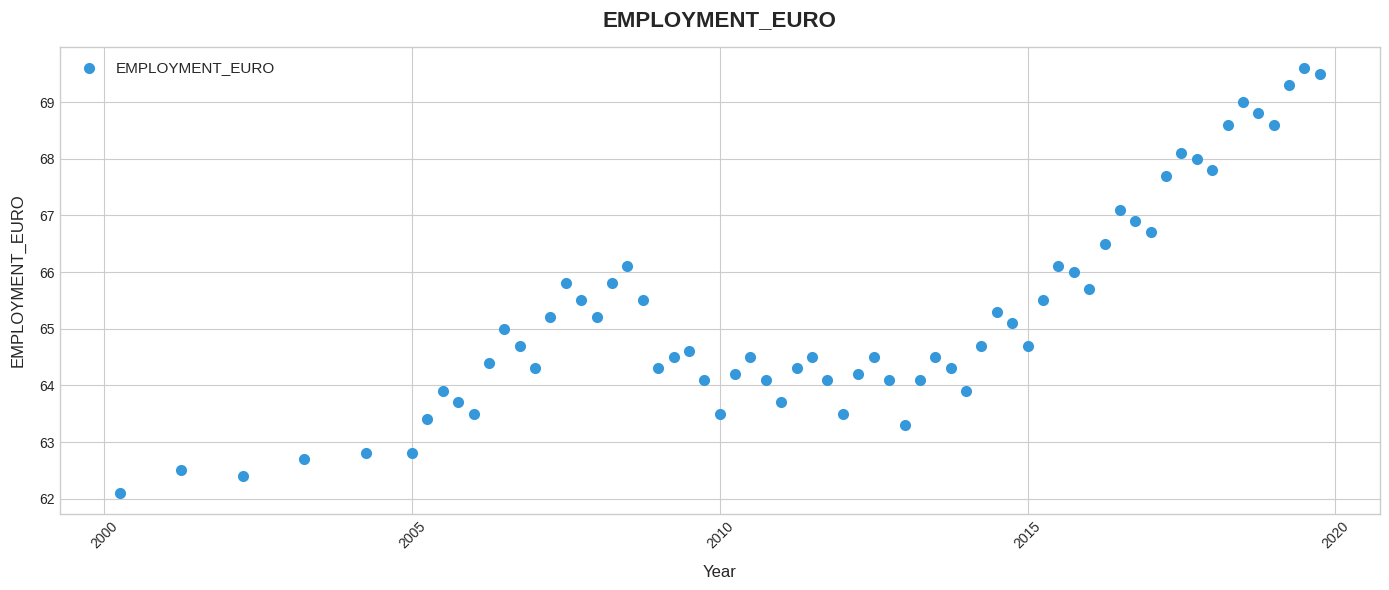

In [ ]:
df_empleo_EURO = df_TODO["EMPLOYMENT_EURO"].loc[dict_fechas["EMPLOYMENT_EURO"][0]:dict_fechas["EMPLOYMENT_EURO"][1]].to_frame()

plot_series(df_empleo_EURO, ['EMPLOYMENT_EURO'], method="scatter")

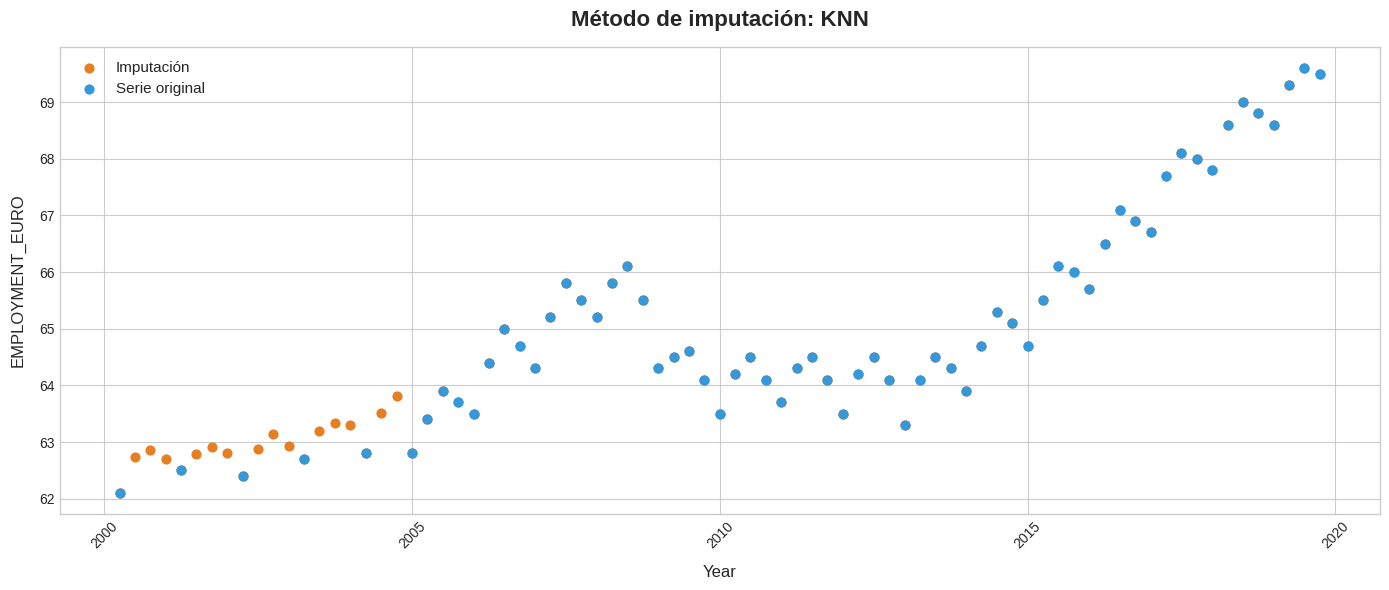

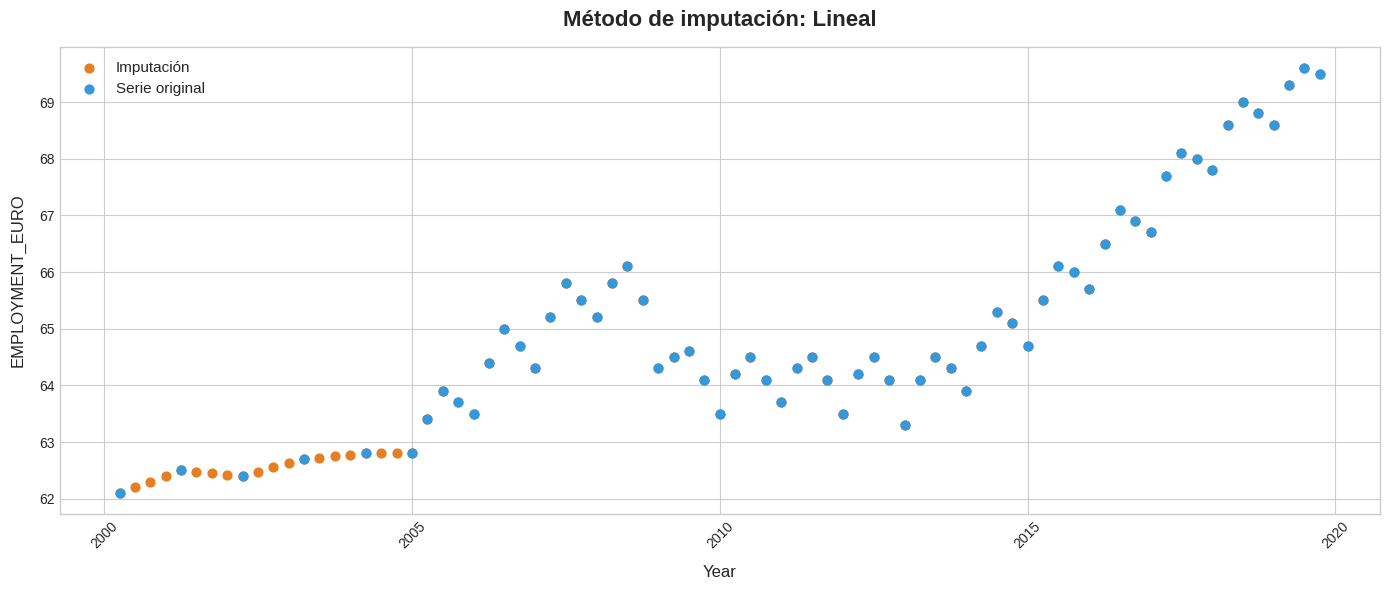

In [ ]:
df_input_empleo_EURO = Imputacion_anual(df_empleo_EURO, 10)
plot_imputaciones(df_input_empleo_EURO, df_empleo_EURO)

En este caso, vemos que el método KNN aproxima mejor la periodicidad de los meses posteriores, por lo que será la opción elegida para la imputación.

In [ ]:
df_TODO["EMPLOYMENT_EURO"] = df_input_empleo_EURO["KNN"]["EMPLOYMENT_EURO"]

### **2.5. Cambio de unidades**

Con el objetivo de poder comparar adecuadamente las categorías económicas entre Estados Unidos y Europa, cambiaremos las unidades de algunas variables.

En primer lugar, pasaremos a millones de dólares las variable GDPREAL_EEUU.

In [ ]:
df_TODO['GDPREAL_EEUU'] = df_TODO['GDPREAL_EEUU'] * 1000

Las variables que representan las importaciones y exportaciones de Europa se expresarán en millones de dólares. La conversión de dólar a euro se hará según los datos de la serie temporal EXCHANGE_EURO_DOLLAR, conociendo así el valor real de las importaciones y exportaciones europeas en cada periodo. Sin embargo, como el euro entró en circulación en 1999, solo tenemos datos del cambio de divisa a partir de ese año. Por este motivo, para los años anteriores se aplicará como referencia el tipo de cambio correspondiente a 1999.

In [ ]:
mask = df_TODO.index >= '1999-01-01'

# Conversión de euros a dólares
for column in ['IMPORTS_EURO', 'EXPORTS_EURO']:

  df_TODO.loc[~mask, column] = (
      df_TODO.loc[~mask, column] *
      df_TODO.loc['1999-01-01', 'EXCHANGE_EURO_DOLLAR']
  )

  df_TODO.loc[mask, column] = (
      df_TODO.loc[mask, column] *
      df_TODO.loc[mask, 'EXCHANGE_EURO_DOLLAR']
  )

  df_TODO[column] = df_TODO[column] / 1000000


Las unidades de las variables HOUSING_STARTS_EURO, INDUSTRIAL_PRODUCTION_EURO y INDUSTRIAL_PRODUCTION_EEUU son índices que muestran cómo ha cambiado un indicador a lo largo del tiempo respecto a un año base. Estableceremos los índices de estas variables en 1980:Q1 = 100 para una mejor comparación.

In [ ]:
for column in ['HOUSING_PRICE_INDEX_EURO', 'INDUSTRIAL_PRODUCTION_EURO', 'INDUSTRIAL_PRODUCTION_EEUU']:
  num = 100 / df_TODO[column]['1980-01-01']
  df_TODO[column] = df_TODO[column] * num

Finalmente, mostraremos en la variable INFLATION_EEUU la tasa de cambio del índice Índice 1982-1984=100 con respecto al periodo del año anterior.

In [ ]:
df_TODO["INFLATION_EEUU"] = df_TODO["INFLATION_EEUU"].pct_change(4) * 100

## **3. Análisis exploratorio**

---

En este apartado, realizaremos un análisis exploratorio de los datos que nos permitirá comparar estadísticamente las economías de Estados Unidos y Europa.

In [ ]:
df_TODO.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184 entries, 1980-01-01 to 2025-10-01
Freq: QS-OCT
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   GDPREAL_EEUU                184 non-null    float64
 1   GDPREAL_EURO                124 non-null    float64
 2   INTEREST_RATES_EEUU         184 non-null    float64
 3   INTEREST_RATES_EURO         184 non-null    float64
 4   INFLATION_EEUU              180 non-null    float64
 5   INFLATION_EURO              177 non-null    float64
 6   INDUSTRIAL_PRODUCTION_EEUU  184 non-null    float64
 7   INDUSTRIAL_PRODUCTION_EURO  172 non-null    float64
 8   HOUSING_PRICE_INDEX_EEUU    184 non-null    float64
 9   HOUSING_PRICE_INDEX_EURO    183 non-null    float64
 10  DEBT_AS_PERCENT_GDP_EEUU    184 non-null    float64
 11  DEBT_AS_PERCENT_GDP_EURO    97 non-null     float64
 12  EMPLOYMENT_EEUU             183 non-null    float64
 13  EMP

El dataset `df_TODO` contiene un total de 184 instancias y 21 columnas, donde todas son de tipo `float64`. Podemos ver que las series relacionadas con Europa poseen valores nulos, lo cual se debe a que el rango de fechas de estas variables es menor que las de EEUU. A continuación, se muestran la fecha de inicio y fin de cada serie europea.

In [ ]:
df_fechas_euro = {}

for nombre in df_TODO.columns:

  if nombre.endswith('_EURO'):

    # Identificamos la fecha de inicio y fin de cada serie
    fecha_ini = df_TODO[nombre].first_valid_index()
    fecha_fin = df_TODO[nombre].last_valid_index()

    # Guardamos las fechas
    df_fechas_euro[nombre] = [fecha_ini, fecha_fin]

df_fechas_euro = pd.DataFrame(df_fechas_euro).T.rename(columns={0: 'Fecha inicio', 1: 'Fecha fin'})
df_fechas_euro

,Fecha inicio,Fecha fin
GDPREAL_EURO,1995-01-01,2025-10-01
INTEREST_RATES_EURO,1980-01-01,2025-10-01
INFLATION_EURO,1980-01-01,2024-01-01
INDUSTRIAL_PRODUCTION_EURO,1980-01-01,2022-10-01
HOUSING_PRICE_INDEX_EURO,1980-01-01,2025-07-01
DEBT_AS_PERCENT_GDP_EURO,1998-01-01,2022-01-01
EMPLOYMENT_EURO,2000-04-01,2019-10-01
IMPORTS_EURO,1990-01-01,2023-01-01
EXPORTS_EURO,1990-01-01,2023-01-01
RECESION_EURO,1980-01-01,2022-07-01


Para una mejor visualización de las conclusiones que hallemos, dividiremos el dataset en dos DataFrames: uno con las variables de EEUU y el otro con las de Europa.

In [ ]:
# Dataframe de Estados Unidos
cols_eeuu = [c for c in df_TODO.columns if c.endswith('_EEUU') and c != 'RECESION_EEUU']
df_eeuu = df_TODO[cols_eeuu]

# Dataframe de Europa
cols_euro = [c for c in df_TODO.columns if c.endswith('_EURO') and c != 'RECESION_EURO']
df_euro = df_TODO[cols_euro]

### **3.1. Tendencia y dispersión**

En primer lugar, calcularemos medidas de tendencia y dispersión con el objetivo de entender mejor la distribución y la estabilidad de los datos, así como las diferencias entre las distintas variables económicas.

In [ ]:
def analisis_exploratorio(df, variables):

  df = df[variables].dropna()

  df_stats = pd.DataFrame({
    "Media": df.mean(),
    "Mediana": df.median(),
    "Moda": df.mode().iloc[0],
    "Coeficiente de asimetría": df.skew(),
    "Rango": df.max() - df.min(),
    "Rango intercuartílico": df.quantile(0.75) - df.quantile(0.25),
    "Percentil 25": df.quantile(0.25),
    "Percentil 50": df.quantile(0.50),
    "Percentil 75": df.quantile(0.75),
    "Desviación típica": df.std(),
    "Varianza": df.var()
  }).round(3)

  return df_stats.T

**EEUU**

In [ ]:
ae_eeuu = analisis_exploratorio(df_TODO, cols_eeuu)
ae_eeuu

,GDPREAL_EEUU,INTEREST_RATES_EEUU,INFLATION_EEUU,INDUSTRIAL_PRODUCTION_EEUU,HOUSING_PRICE_INDEX_EEUU,DEBT_AS_PERCENT_GDP_EEUU,EMPLOYMENT_EEUU,IMPORTS_EEUU,EXPORTS_EEUU
Media,1.474744e+07,4.223,3.098,159.920,295.630,73.635,70.424,4.531435e+05,3.540082e+05
Mediana,1.474357e+07,4.327,2.817,175.042,282.810,62.770,71.079,3.868530e+05,2.781960e+05
Moda,7.295631e+06,0.090,-1.607,90.665,105.070,30.603,62.698,7.191800e+04,6.656600e+04
Coeficiente de asimetría,1.200000e-01,1.070,1.521,-0.589,0.957,0.452,-0.606,3.730000e-01,4.490000e-01
Rango,1.673120e+07,17.720,12.868,110.621,600.250,102.060,11.694,1.007705e+06,7.745560e+05
Rango intercuartílico,8.004494e+06,4.942,1.817,69.911,199.285,44.710,3.378,5.361240e+05,4.086650e+05
Percentil 25,1.029193e+07,1.000,1.891,121.210,172.585,55.591,68.635,1.647865e+05,1.567070e+05
Percentil 50,1.474357e+07,4.327,2.817,175.042,282.810,62.770,71.079,3.868530e+05,2.781960e+05
Percentil 75,1.829643e+07,5.942,3.708,191.122,371.870,100.301,72.012,7.009105e+05,5.653720e+05
Desviación típica,4.720004e+06,3.693,1.938,35.387,150.973,27.082,2.401,2.936591e+05,2.275139e+05


**Europa**

In [ ]:
ae_euro = analisis_exploratorio(df_TODO, cols_euro)
ae_euro

,GDPREAL_EURO,INTEREST_RATES_EURO,INFLATION_EURO,INDUSTRIAL_PRODUCTION_EURO,HOUSING_PRICE_INDEX_EURO,DEBT_AS_PERCENT_GDP_EURO,EMPLOYMENT_EURO,IMPORTS_EURO,EXPORTS_EURO
Media,2.771617e+06,3.238,1.926,143.885,432.225,76.608,64.840,4.706204e+05,4.924514e+05
Mediana,2.790648e+06,3.837,2.176,143.610,447.957,75.341,64.300,4.994992e+05,5.525544e+05
Moda,2.412496e+06,0.168,-0.062,135.128,437.809,57.855,64.100,2.138804e+05,2.222910e+05
Coeficiente de asimetría,1.350000e-01,-0.542,-0.307,0.030,-0.646,0.165,0.966,-6.520000e-01,-5.600000e-01
Rango,7.605199e+05,5.271,4.227,34.746,242.254,45.451,7.500,4.372845e+05,4.593687e+05
Rango intercuartílico,2.602964e+05,2.764,1.423,8.096,59.924,27.299,2.300,2.046912e+05,2.346488e+05
Percentil 25,2.609028e+06,1.525,1.201,139.755,402.852,63.074,63.450,3.807730e+05,3.846915e+05
Percentil 50,2.790648e+06,3.837,2.176,143.610,447.957,75.341,64.300,4.994992e+05,5.525544e+05
Percentil 75,2.869324e+06,4.289,2.625,147.851,462.776,90.373,65.750,5.854642e+05,6.193403e+05
Desviación típica,2.022066e+05,1.480,1.030,7.495,59.062,13.871,1.911,1.343951e+05,1.471432e+05


En general, se puede observar que Estados Unidos presenta una mayor tendencia central en la mayoría de los indicadores económicos, especialmente en el GPD, los tipos de interés, la inflación, la producción industrial y el empleo. Esto puede indicar que la economía es de mayor tamaño y que los ciclos económicos están más marcados. También se observa en estas variables una dispersión mayor, lo que sugiere que esta economía ha experimentado fluctuaciones más intensas en el tiempo.

Por otro lado, Europa presenta valores más estables en muchas variables. Sin embargo, en variables como la deuda pública o las exportaciones, la tendencia media es mayor, lo que indica una mayor dependencia del comercio internacional.


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Coeficientes de asimetría: EEUU vs Europa'}, ylabel='Coeficiente de asimetría'>)

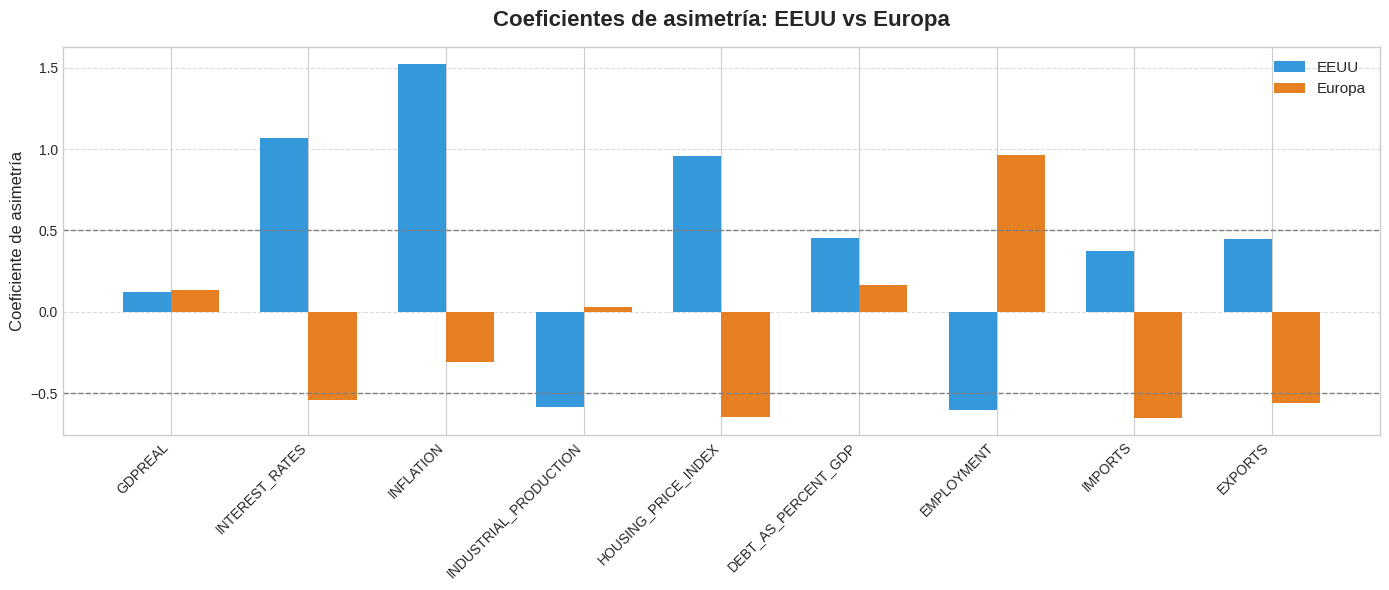

In [ ]:
asi_eeuu = ae_eeuu.loc['Coeficiente de asimetría']
asi_euro = ae_euro.loc['Coeficiente de asimetría']

# Eliminamos los sufijos "_EEUU" y "_EURO"
asi_eeuu.index = asi_eeuu.index.str.replace('_EEUU', '')
asi_euro.index = asi_euro.index.str.replace('_EURO', '')

# Pasamos ambas series a diccionario
asi_eeuu = asi_eeuu.to_dict()
asi_euro = asi_euro.to_dict()

# Mostramos los coeficientes de asimetría gráficamente
plot_asimetria_style(asi_eeuu, asi_euro, nombre_region1='EEUU', nombre_region2='Europa', ax=None)

En cuanto a los coeficientes de asimetría, se observa en la gráfica que muchas variables presentan distribuciones moderadamente sesgadas ya que sus coeficientes de asimetría superan las cotas de -0.5 y 0.5. Puede apreciarse también que EEUU presenta mayoritariamente coeficientes positivos, lo que sugiere la presencia de episodios económicos con valores particularmente altos, especialmente en la inflación, los tipos de interés o los precios de la vivienda. En cambio, a excepción del empleo, en Europa predominan asimetrías negativas o cercanas a 0, dando a entender que las distribuciones tienden a concentrarse en torno a la media o presentan episodios en los que los indicadores han tomado valores relativamente más bajos de lo habitual.

### **3.2. Correlación entre variables**

En este apartado miraremos si la evolución temporal entre las series correspondientes a factores económicos de Estados Unidos y de Europa han seguido la misma tendencia a lo largo del tiempo. Además, también veremos cómo estos factores se han visto influenciados entre ellos a partir de las variaciones trimestres consecutivas en cada sector económico (para esto se utilizará el método `.diff`).

Dividiremos las correlaciones en 3 partes:

  1. Correlación entre variables de Estados Unidos.
  2. Correlación entre variables de Europa.
  3. Correlación cruzada de variables de Estados Unidos con variables de Europa.

In [ ]:
df_eeuu  = df_TODO[cols_eeuu].dropna()
df_euro  = df_TODO[cols_euro].dropna()
df_cross = df_TODO[cols_eeuu + cols_euro].dropna()

In [ ]:
df_eeuu  = df_TODO[cols_eeuu].dropna()
df_euro  = df_TODO[cols_euro].dropna()
df_cross = df_TODO[cols_eeuu + cols_euro].dropna()

pares_cross = pd.DataFrame(
    [(e, u, round(df_cross[e].corr(df_cross[u]), 4))
     for e in cols_eeuu for u in cols_euro],
    columns=['Variable EEUU', 'Variable Europa', 'Correlación']
).sort_values('Correlación', key=abs, ascending=False)


# ── Función para obtener la correlación por pares.
def pares_correlacion(corr_df):
    mask  = np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    pares = corr_df.where(mask).stack().reset_index()
    pares.columns = ['Variable A', 'Variable B', 'Correlación']
    return pares.sort_values('Correlación', key=abs, ascending=False)



#### **3.3.1. Correlación de variables de EEUU**

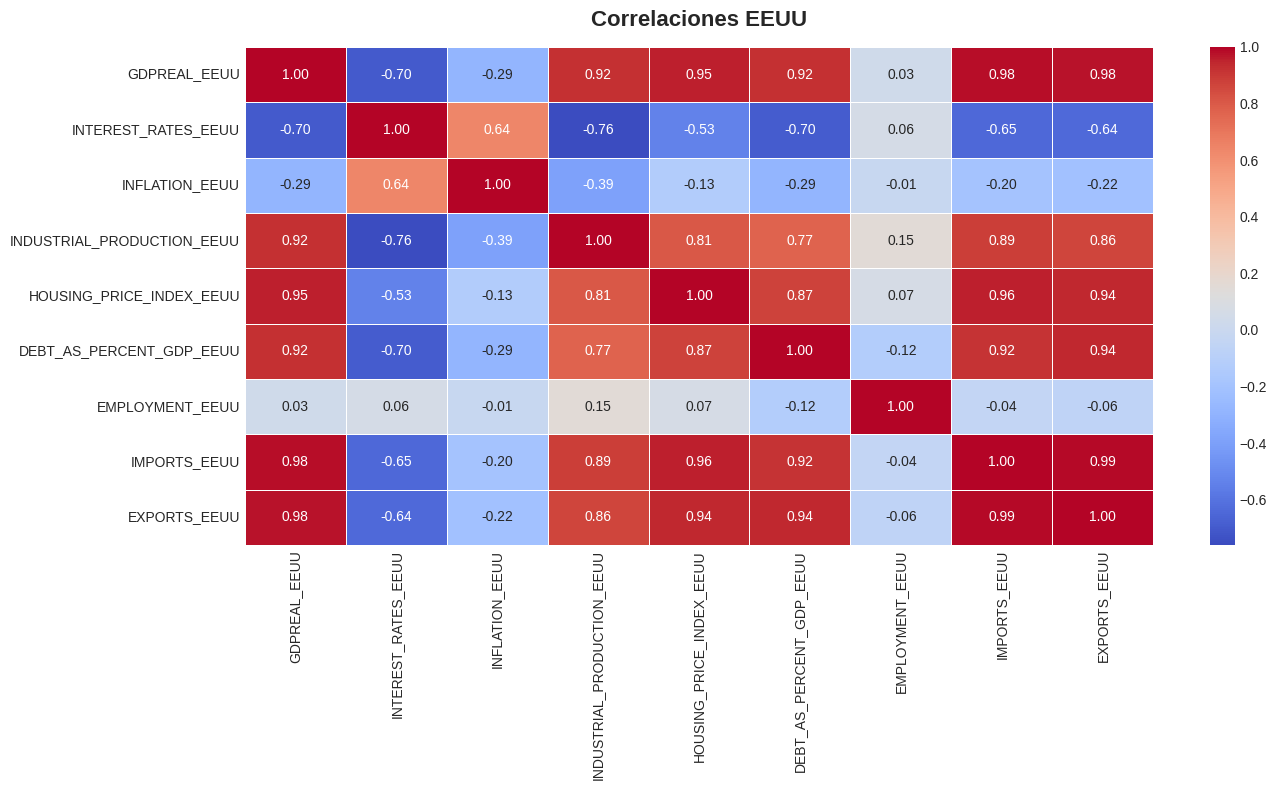

In [ ]:
corr_eeuu = df_eeuu.corr()
plot_heatmap(corr_eeuu, 'Correlaciones EEUU')

In [ ]:
# ── Top correlaciones internas EEUU
pares_eeuu = pares_correlacion(df_eeuu.corr())
print(' Top 10 mayores correlaciones internas — EEUU')
print(pares_eeuu.head(10).to_string(index=False))
print('\n Top 10 menores correlaciones internas — EEUU')
print(pares_eeuu.tail(10).to_string(index=False))

 Top 10 mayores correlaciones internas — EEUU
              Variable A                 Variable B  Correlación
            IMPORTS_EEUU               EXPORTS_EEUU     0.991429
            GDPREAL_EEUU               IMPORTS_EEUU     0.983981
            GDPREAL_EEUU               EXPORTS_EEUU     0.976014
HOUSING_PRICE_INDEX_EEUU               IMPORTS_EEUU     0.956274
            GDPREAL_EEUU   HOUSING_PRICE_INDEX_EEUU     0.954331
DEBT_AS_PERCENT_GDP_EEUU               EXPORTS_EEUU     0.944298
HOUSING_PRICE_INDEX_EEUU               EXPORTS_EEUU     0.939125
            GDPREAL_EEUU INDUSTRIAL_PRODUCTION_EEUU     0.923651
            GDPREAL_EEUU   DEBT_AS_PERCENT_GDP_EEUU     0.922787
DEBT_AS_PERCENT_GDP_EEUU               IMPORTS_EEUU     0.916450

 Top 10 menores correlaciones internas — EEUU
                Variable A               Variable B  Correlación
            INFLATION_EEUU             IMPORTS_EEUU    -0.201600
INDUSTRIAL_PRODUCTION_EEUU          EMPLOYMENT_EEUU     0.1532

En general, puede observarse que la mayoría de las categorías económicas de Estados Unidos han seguido una tendencia de crecimiento similar durante los últimos años, lo que sugiere que estas variables tienden a ir de la mano cuando la actividad económica estadounidense aumenta o disminuye. Por otro lado, vemos que los tipos de interés presentan una relación negativa con varias de estas variables, indicando que, a lo largo de los años, los tipos de interés han seguido una evolución contraria al resto de variables económicas. También puede verse que el empleo y la inflación muestran una correlación muy débil con la mayoría de las variables.

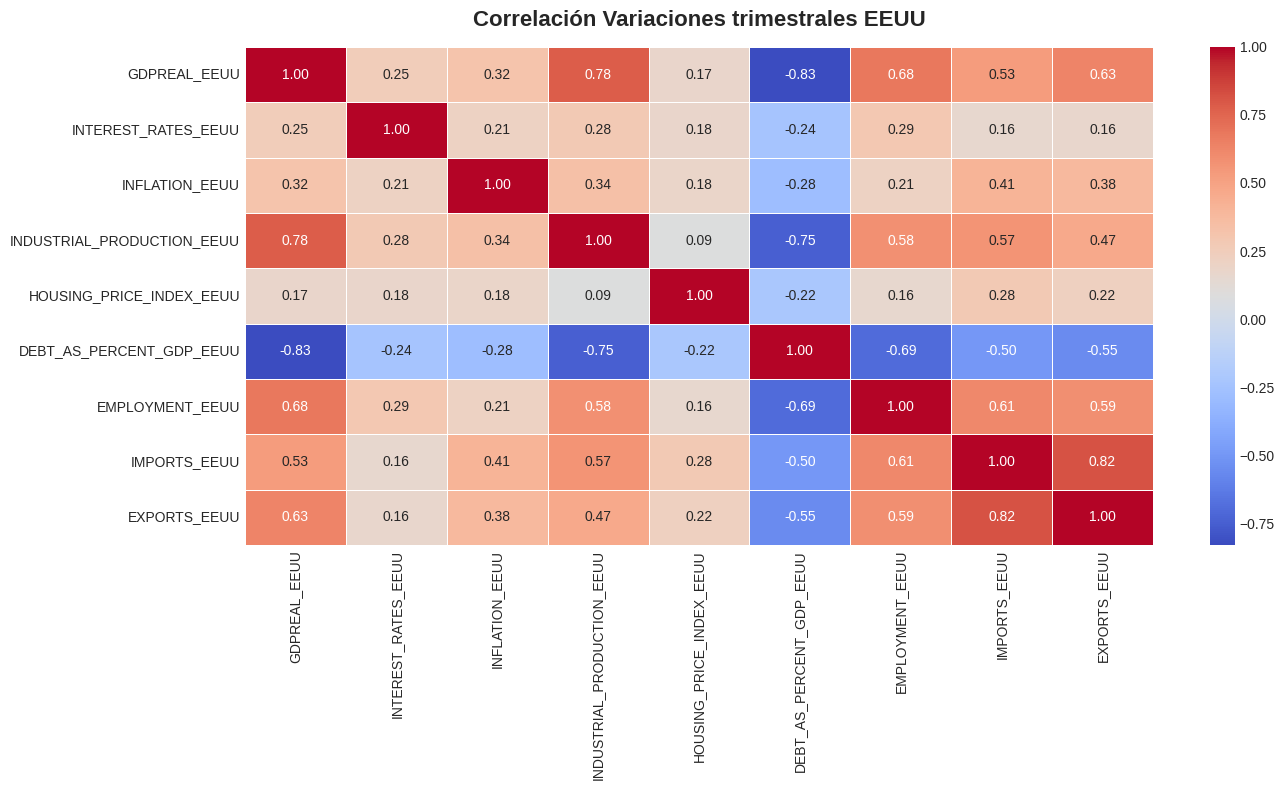

In [ ]:
corr_diff_df_eeuu = df_eeuu.diff().corr()
plot_heatmap(corr_diff_df_eeuu, 'Correlación Variaciones trimestrales EEUU')

Estudiando las variaciones trimestrales de cada sector de Estados Unidos se puede ver claramente que, durante los últimos años, la producción industrial, las importaciones y las exportaciones han sido factores relevantes en el crecimiento de la economía estadounidense, lo cual se puede ver reflejado en las correlaciones de estas variables con el GDP. Además, el crecimiento del GDP y de la producción industrial se ha traducido en una reducción de la deuda pública y un ligero aumento del empleo. También puede verse que el aumento de las importaciones en un trimestre da lugar a un aumento de las exportaciones.

#### **3.2.2. Correlación de variables de Europa**

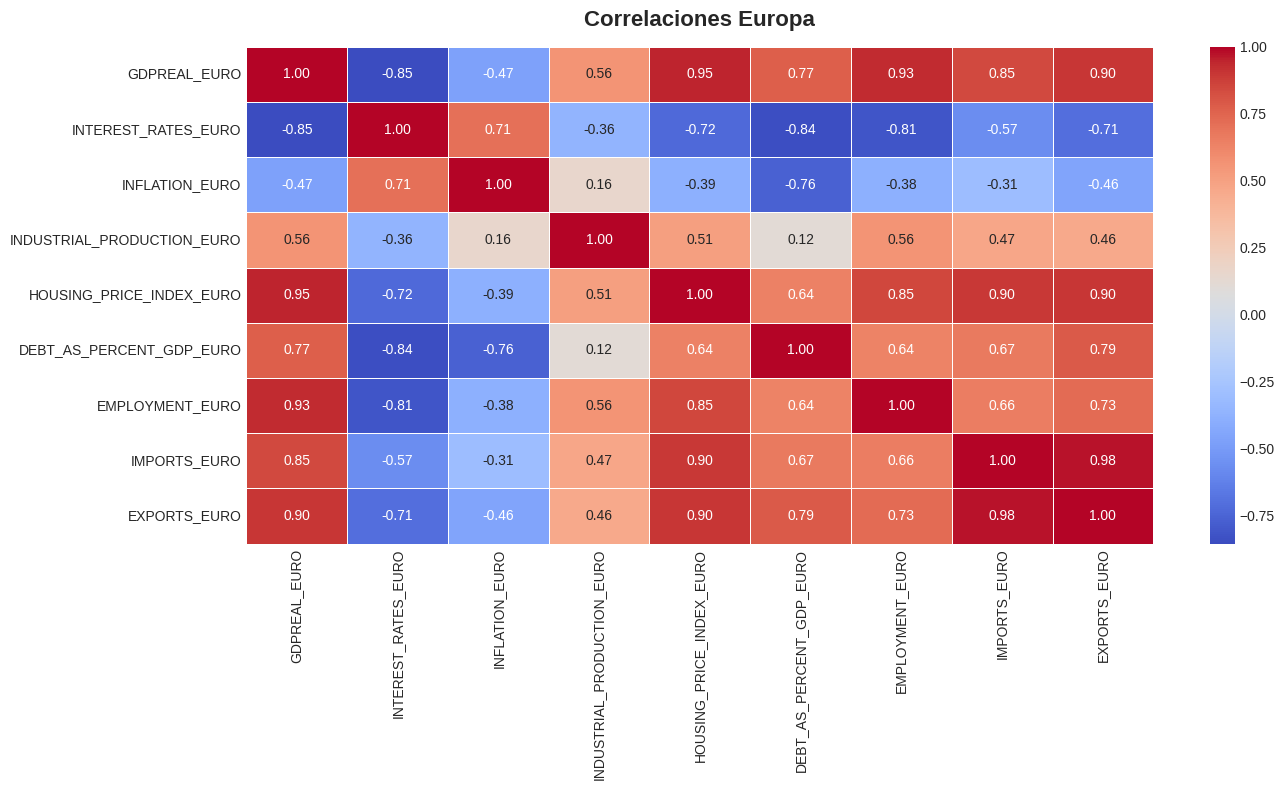

In [ ]:
corr_euro = df_euro.corr()
plot_heatmap(corr_euro, 'Correlaciones Europa')

In [ ]:
# ── Top correlaciones internas EURO
pares_euro = pares_correlacion(df_euro.corr())
print('Top 10 mayores correlaciones internas — Europa')
print(pares_euro.head(10).to_string(index=False))
print('\n Top 10 menores correlaciones internas — Europa')
print(pares_euro.tail(10).to_string(index=False))

Top 10 mayores correlaciones internas — Europa
              Variable A               Variable B  Correlación
            IMPORTS_EURO             EXPORTS_EURO     0.976442
            GDPREAL_EURO HOUSING_PRICE_INDEX_EURO     0.946393
            GDPREAL_EURO          EMPLOYMENT_EURO     0.932571
HOUSING_PRICE_INDEX_EURO             EXPORTS_EURO     0.904094
            GDPREAL_EURO             EXPORTS_EURO     0.901941
HOUSING_PRICE_INDEX_EURO             IMPORTS_EURO     0.898359
            GDPREAL_EURO      INTEREST_RATES_EURO    -0.853907
HOUSING_PRICE_INDEX_EURO          EMPLOYMENT_EURO     0.849555
            GDPREAL_EURO             IMPORTS_EURO     0.845501
     INTEREST_RATES_EURO DEBT_AS_PERCENT_GDP_EURO    -0.840804

 Top 10 menores correlaciones internas — Europa
                Variable A                 Variable B  Correlación
INDUSTRIAL_PRODUCTION_EURO               IMPORTS_EURO     0.474358
              GDPREAL_EURO             INFLATION_EURO    -0.466566
INDUSTRIAL

En Europa vemos que la evolución temporal de los distintos sectores económicos sigue la misma tendencia. Sin embargo, las correlaciones entre variables no son tan altas como en el caso de Estados Unidos, especialmente en el caso de la producción industrial, que muestra una relación más moderada con el GDP y otros indicadores. Además, destaca que, a diferencia de Estados Unidos, el empleo en Europa ha evolucionado a la vez que el GDP y la vivienda, reflejando una mayor conexión entre la actividad económica y el mercado laboral, así como con el sector inmobiliario.

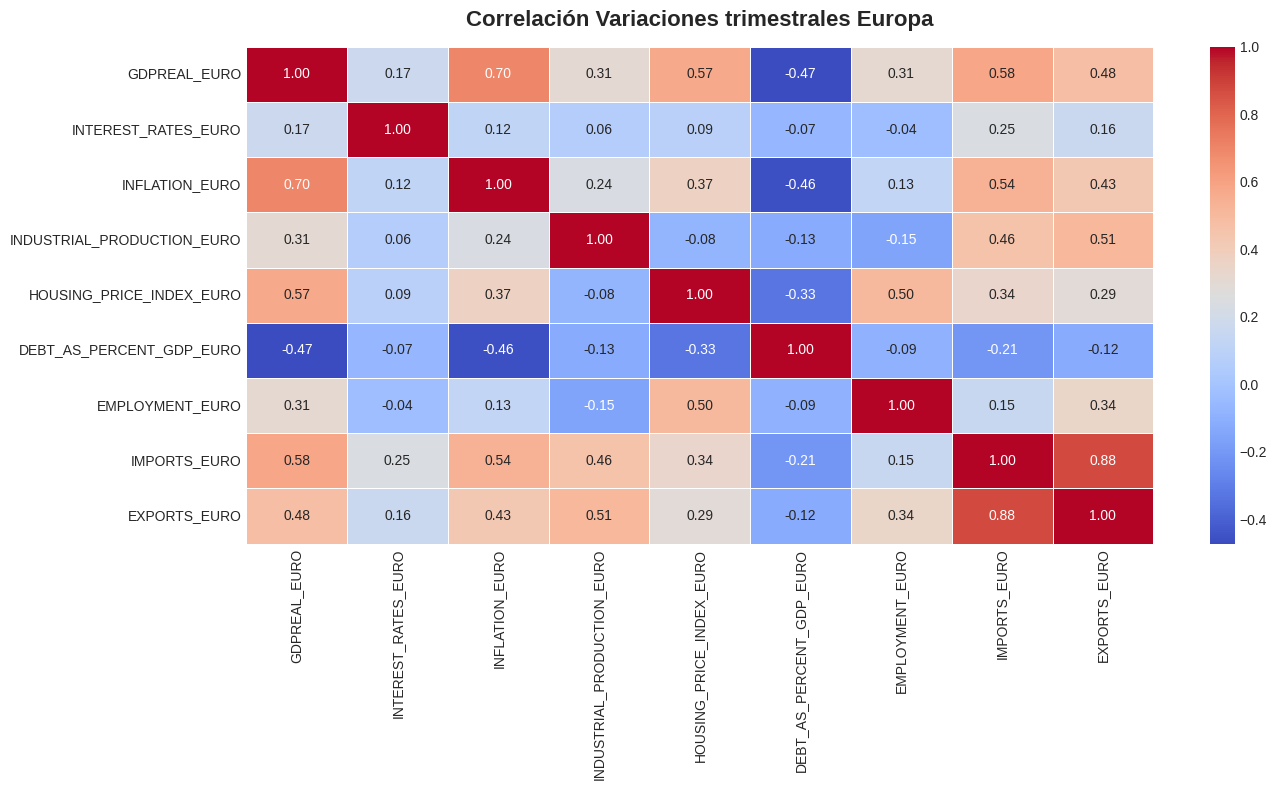

In [ ]:
corr_euro = df_euro.diff().corr()
plot_heatmap(corr_euro, 'Correlación Variaciones trimestrales Europa')

En cuanto a la variación trimestral en Europa, se observa que los incrementos del GDP en los últimos años han ido acompañados de un aumento de la inflación y de los precios de las propiedades residenciales. Por otro lado, vemos que tanto las importaciones como las exportaciones son factores clave del crecimiento económico y presentan una relación muy estrecha entre sí, mostrando que los movimientos del comercio exterior tienden a ocurrir de forma coordinada.

#### **3.2.3. Correlación de variables cruzadas**

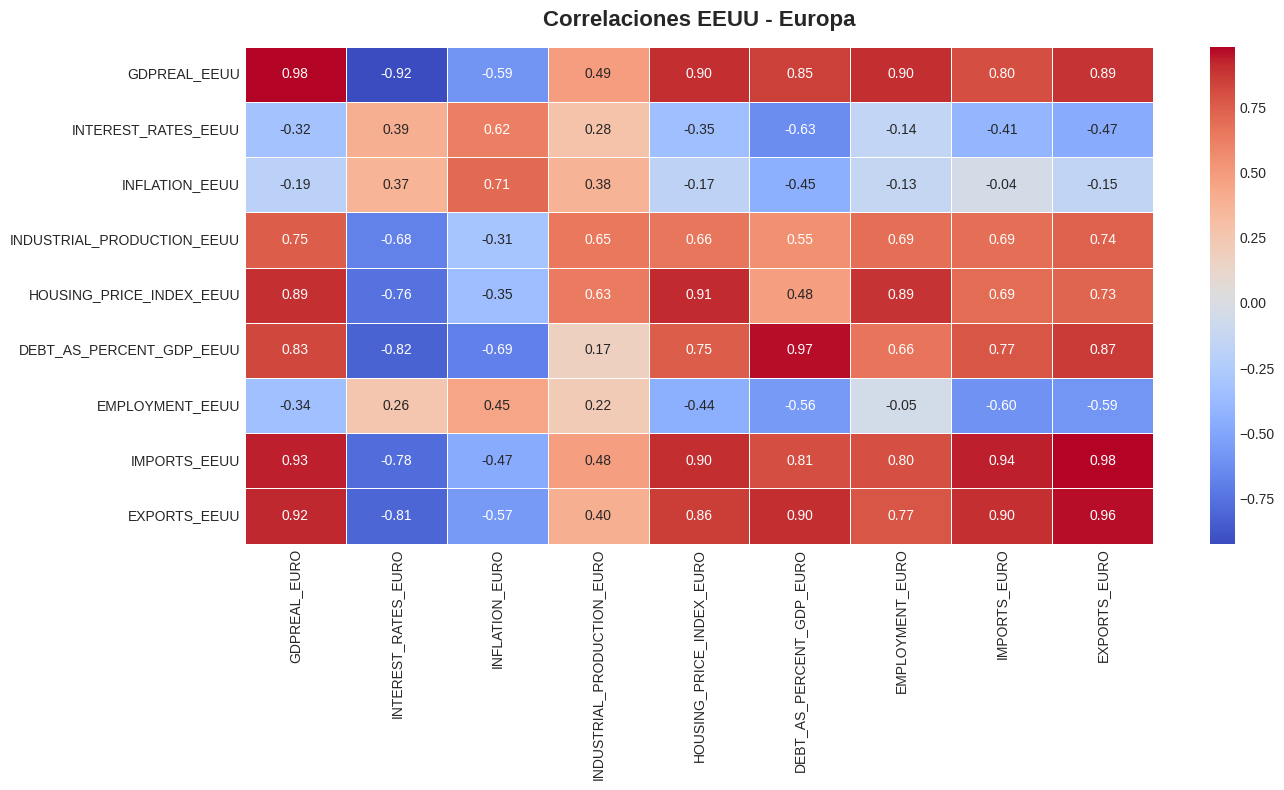

In [ ]:
corr_cross = df_cross.corr().loc[:'EXPORTS_EEUU', 'GDPREAL_EURO':]
plot_heatmap(corr_cross, 'Correlaciones EEUU - Europa')

In [ ]:
# ── Top correlaciones cruzadas
print('Top 10 mayores correlaciones cruzadas — EEUU × Europa')
print(pares_cross.head(10).to_string(index=False))
print('\n  Top 10 menores correlaciones cruzadas — EEUU × Europa')
print(pares_cross.tail(10).to_string(index=False))

Top 10 mayores correlaciones cruzadas — EEUU × Europa
           Variable EEUU          Variable Europa  Correlación
            GDPREAL_EEUU             GDPREAL_EURO       0.9812
            IMPORTS_EEUU             EXPORTS_EURO       0.9755
DEBT_AS_PERCENT_GDP_EEUU DEBT_AS_PERCENT_GDP_EURO       0.9650
            EXPORTS_EEUU             EXPORTS_EURO       0.9628
            IMPORTS_EEUU             IMPORTS_EURO       0.9350
            IMPORTS_EEUU             GDPREAL_EURO       0.9334
            GDPREAL_EEUU      INTEREST_RATES_EURO      -0.9226
            EXPORTS_EEUU             GDPREAL_EURO       0.9204
HOUSING_PRICE_INDEX_EEUU HOUSING_PRICE_INDEX_EURO       0.9082
            IMPORTS_EEUU HOUSING_PRICE_INDEX_EURO       0.9049

  Top 10 menores correlaciones cruzadas — EEUU × Europa
           Variable EEUU            Variable Europa  Correlación
         EMPLOYMENT_EEUU        INTEREST_RATES_EURO       0.2576
         EMPLOYMENT_EEUU INDUSTRIAL_PRODUCTION_EURO       0.2171
 

Conjuntamente puede verse que, en la mayoría de aspectos económicos, ambas economías han crecido de forma simultánea. Los tipos de interés de Europa han seguido generalmente una tendencia contraria a la de los sectores económicos de Estados Unidos y el empleo estadounidense experimenta un ligero crecimiento contrario a los factores europeos.

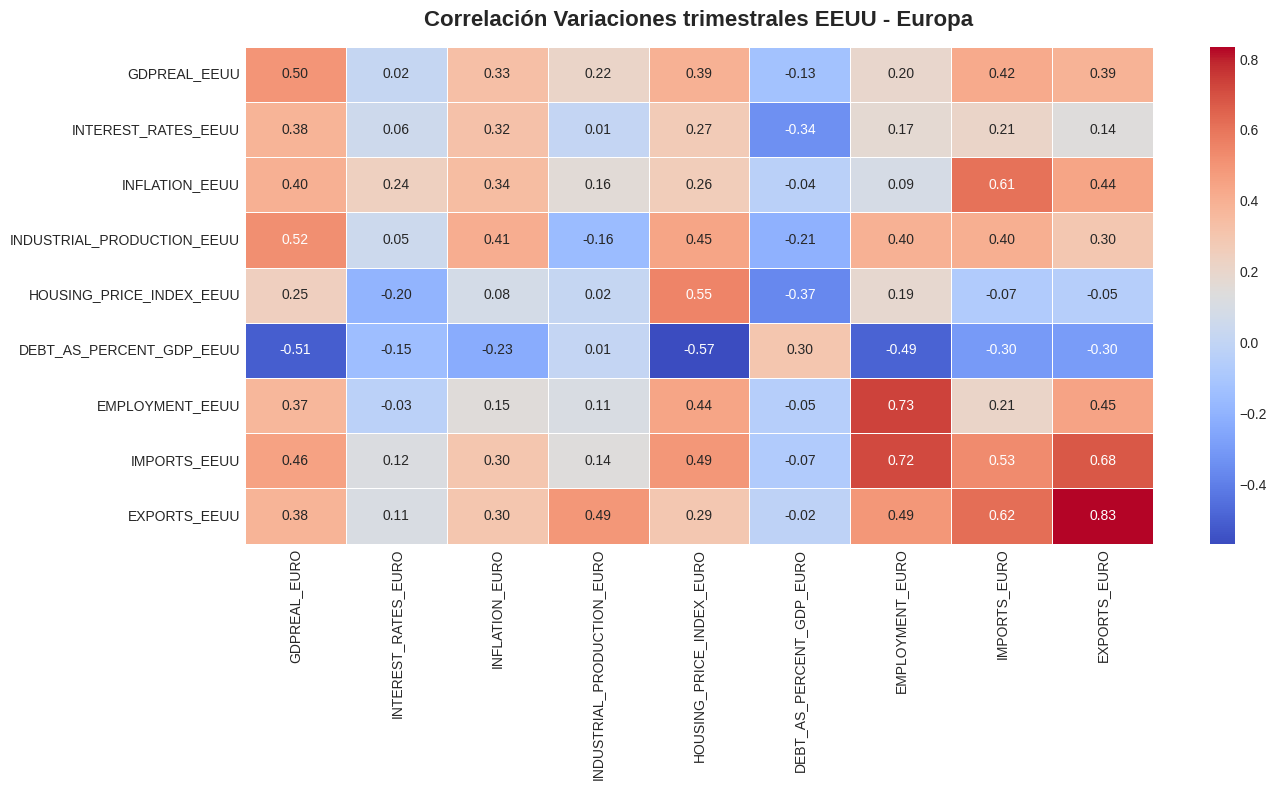

In [ ]:
corr_cross = df_cross.diff().corr().loc[:'EXPORTS_EEUU', 'GDPREAL_EURO':]
plot_heatmap(corr_cross, 'Correlación Variaciones trimestrales EEUU - Europa')

El análisis de las correlaciones muestra que la economía de Estados Unidos y la europea están moderadamente interconectadas. El GDP estadounidense se relaciona ligeramente con el GDP, la vivienda, la inflación y el comercio europeo, aunque tiene poca influencia sobre la producción industrial y el empleo europeos. Por su parte, el empleo en EEUU se mueve de manera muy cercana al empleo europeo y moderadamente con vivienda y exportaciones. Además, las exportaciones e importaciones de ambos territorios presentan correlaciones altas positivamente, lo que muestra que existe un fuerte comercio entre ambas regiones. En cambio, la deuda estadounidense muestra correlaciones negativas con el GDP, la vivienda y el empleo europeos, sugiriendo que un mayor endeudamiento puede limitar la expansión de algunos sectores en Europa.

## **4. Comparación de indicadores**

---

En este apartado iremos indicador a indicador haciendo un breve análisis de la información que obtengamos a partir de los gráficos que vayamos haciendo. De esta forma obtendremos una comparación entre ambas economías en un contexto global.

### **4.1. Comparación de recesiones**

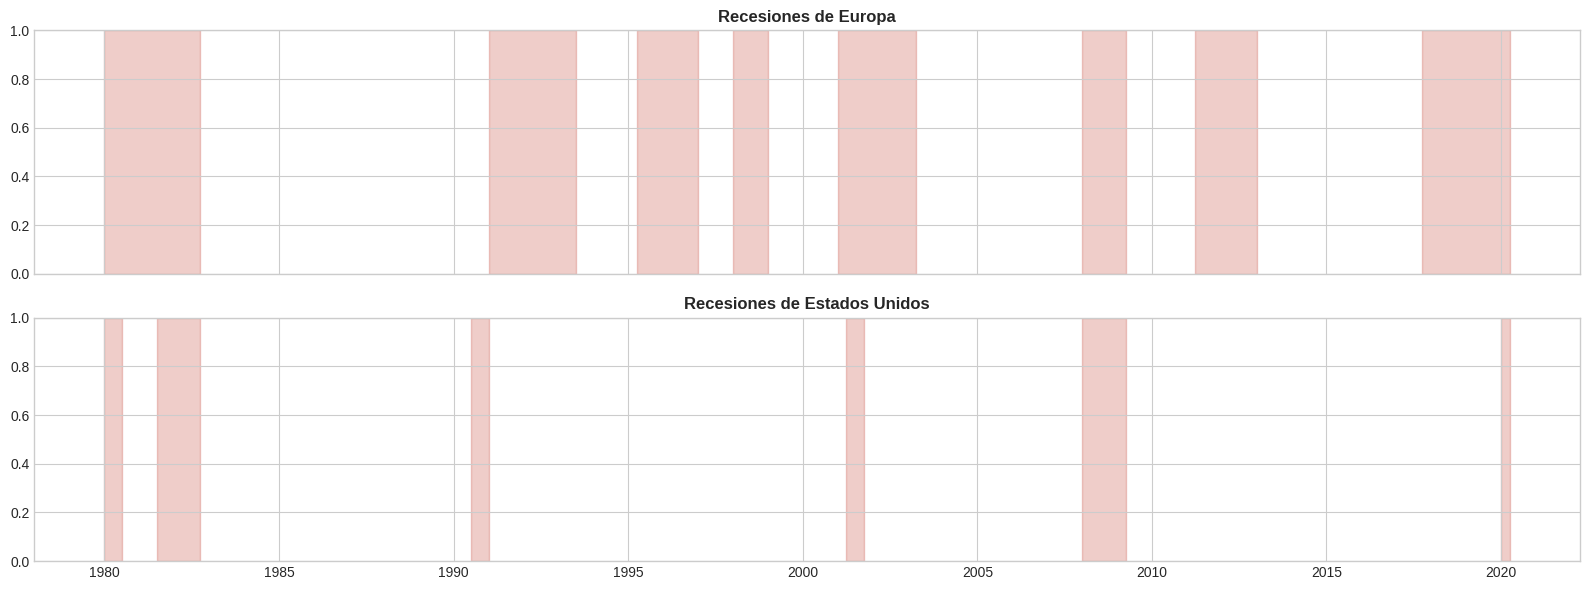

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# Gráfico Europa

ax1 = axes[0]
shade_recessions(
    ax1,
    df_TODO['RECESION_EURO'],
    color='#c0392b',
    alpha=0.25
)

ax1.set_title('Recesiones de Europa', fontweight='bold')


# Gráfico Estados Unidos

ax2 = axes[1]

shade_recessions(
    ax2,
    df_TODO['RECESION_EEUU'],
    color='#c0392b',
    alpha=0.25
)

ax2.set_title('Recesiones de Estados Unidos', fontweight='bold')


plt.tight_layout()
plt.show()

Al comparar un gráfico debajo del otro, podemos ver que Europa presenta más recesiones desde 1980. De hecho, sacando cuentas, tenemos:

In [ ]:
df_TODO['RECESION_EURO'].value_counts()

,count
RECESION_EURO,
0.0,100
1.0,71


In [ ]:
df_TODO['RECESION_EEUU'].value_counts()

,count
RECESION_EEUU,
0.0,161
1.0,23


Es decir, de las 184 observaciones, Europa ha tenido 71 que son recesiones, mientras que Estados Unidos ha tenido 3 veces menos.

Si hablamos de proporciones un 38 \% del tiempo desde 1980 Europa ha estado en recesión y, sin embargo, Estados Unidos ha estado en recesión un 12 \%.

Analizando ahora las recesiones, nos surge la siguiente pregunta: ¿A qué se han debido estas crisis? Esta información la podemos encontrar en los siguientes enlaces:

Recesiones Estados Unidos : https://es.wikipedia.org/wiki/Anexo:Recesiones_en_Estados_Unidos

Recesiones Europa: https://elordenmundial.com/mapas-y-graficos/recesiones-eurozona/

In [ ]:
# Descripciones de las crisis
labels_recesiones_EEUU = [
    "Recesión 1980",
    "Recesión 1981-82 - Revolución Iraní",
    "Recesión 1990-91 - Acumulación de deuda y precio del petroleo",
    "Crisis puntocom 2001",
    "Gran Recesión - Crisis Hipotecaria 2008-09",
    "COVID-19 2020"
]

labels_recesiones_Europa = [
    "Recesión principios de los 80 (1980‑82)",
    "Recesión principios de los 90 (1992‑93)",
    "Recesión de los 90 (1996‑97)",
    "Recesión del 98",
    "Crisis puntocom 2001",
    "Gran Recesión (2008‑09) – Crisis Hipotecaria",
    "Crisis del euro (2011‑13)",
    "COVID‑19 (2020‑21)",
    "Guerra de Ucrania (2022‑24)"
]

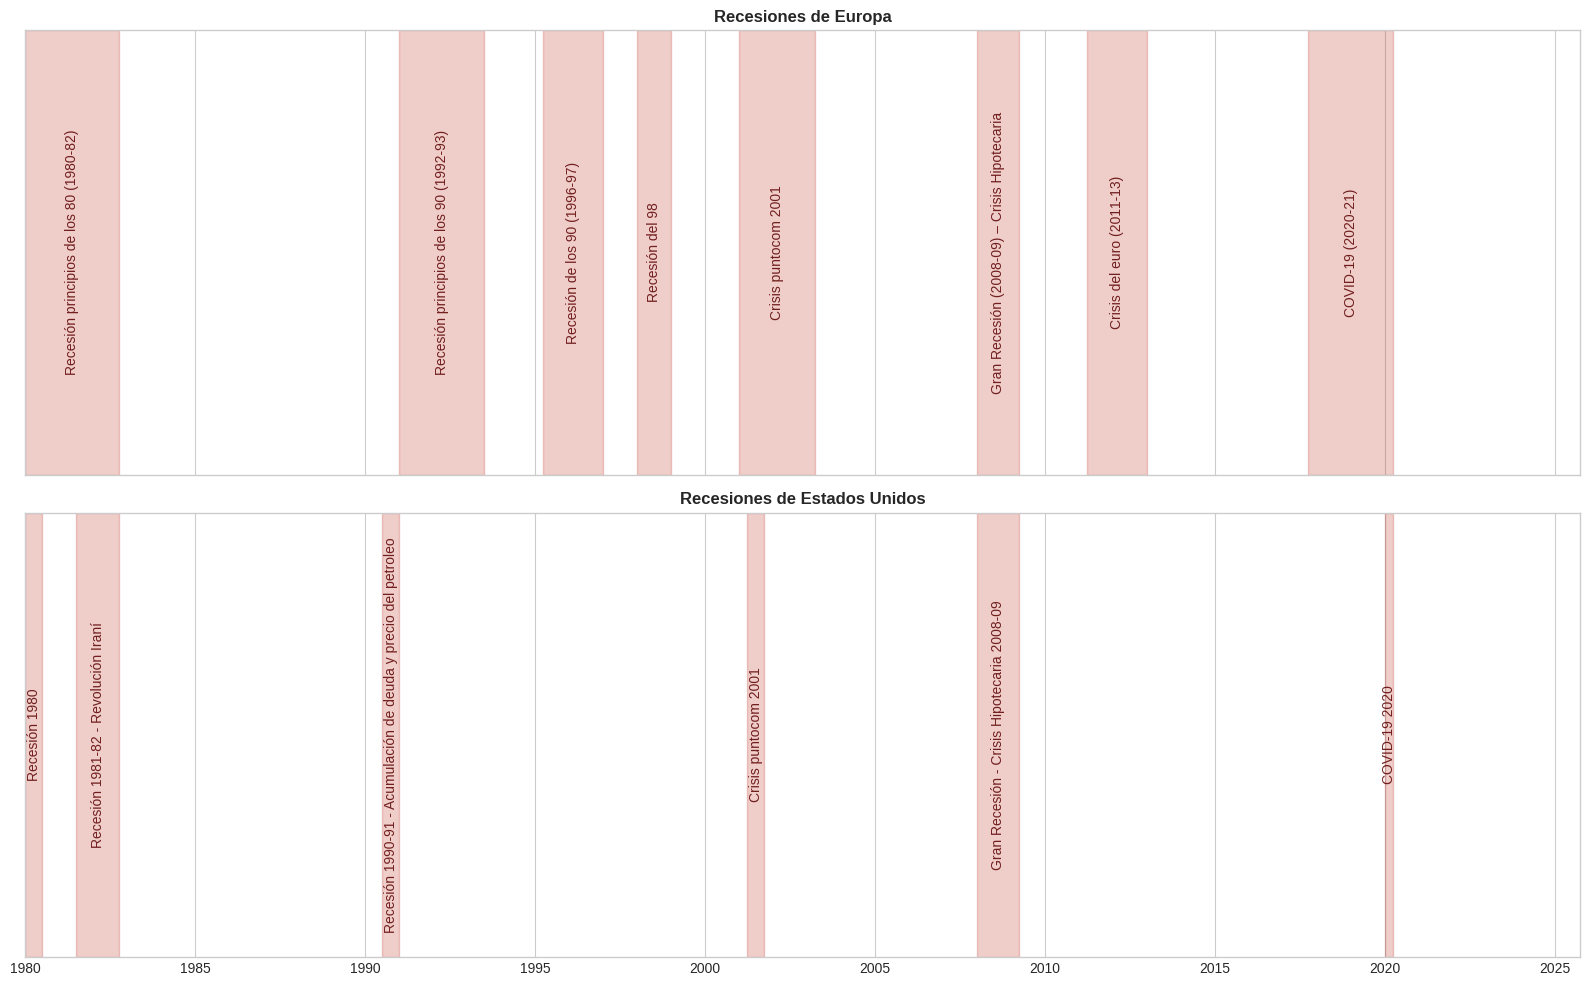

In [ ]:

# -----------------------------
# Gráfico
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Europa ---
ax1 = axes[0]
shade_recessions_with_labels(ax1, df_TODO['RECESION_EURO'], labels_recesiones_Europa)
ax1.set_title('Recesiones de Europa', fontweight='bold')
ax1.set_ylim(0, 1)
ax1.set_yticks([])  # Ocultar eje Y (no aporta info)

# --- Estados Unidos ---
ax2 = axes[1]
shade_recessions_with_labels(ax2, df_TODO['RECESION_EEUU'], labels_recesiones_EEUU)
ax2.set_title('Recesiones de Estados Unidos', fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_yticks([])

# --- Ajuste X compartido ---
xmin = df_TODO.index.min()
xmax = df_TODO.index.max()
ax1.set_xlim(xmin, xmax)
# ax2 hereda xlim por sharex=True

plt.tight_layout()
plt.show()

Las economías estadounidense y europea comparten las crisis protagonizadas por la Revolución Iraní de 1981-1982, la Crisis PuntoCom, la crisis inmobiliaria y la del COVID. Aunque todas estas, en comparación, duran menos en Estados Unidos.

### **4.2. Comparación de GDP**

En este apartado veremos la evolución del GDP en ambas economías. Veremos cuánto han influido estas recesiones y veremos de forma cuantitativa su influencia.

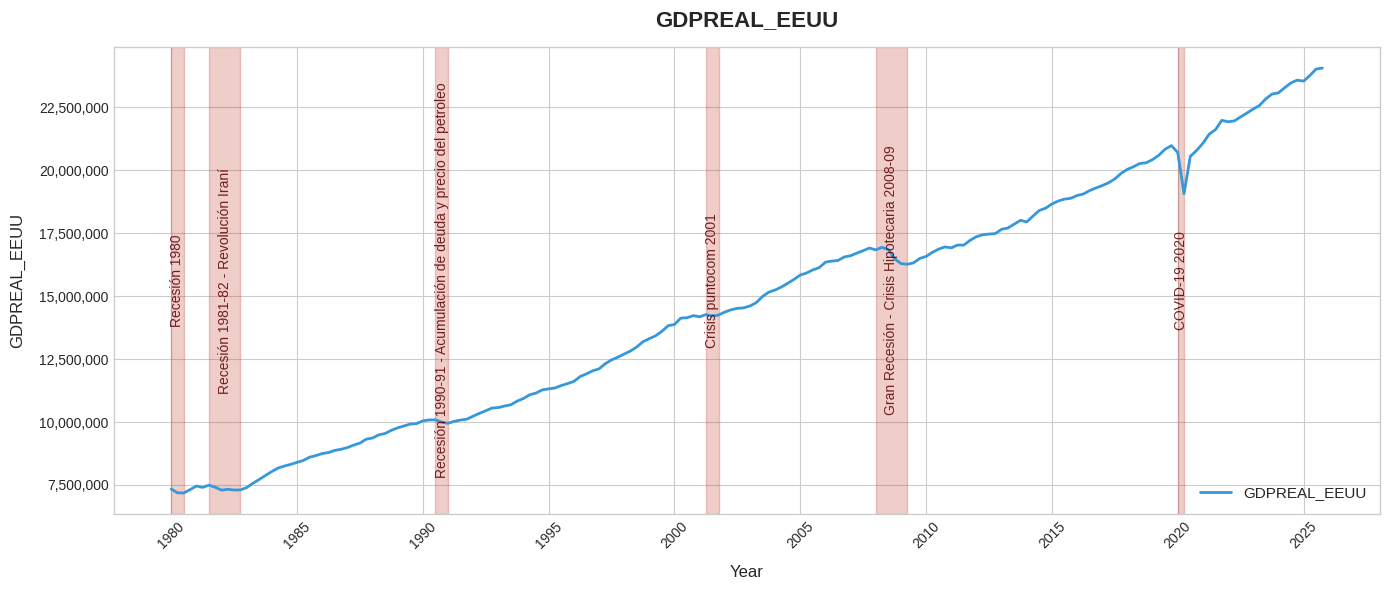

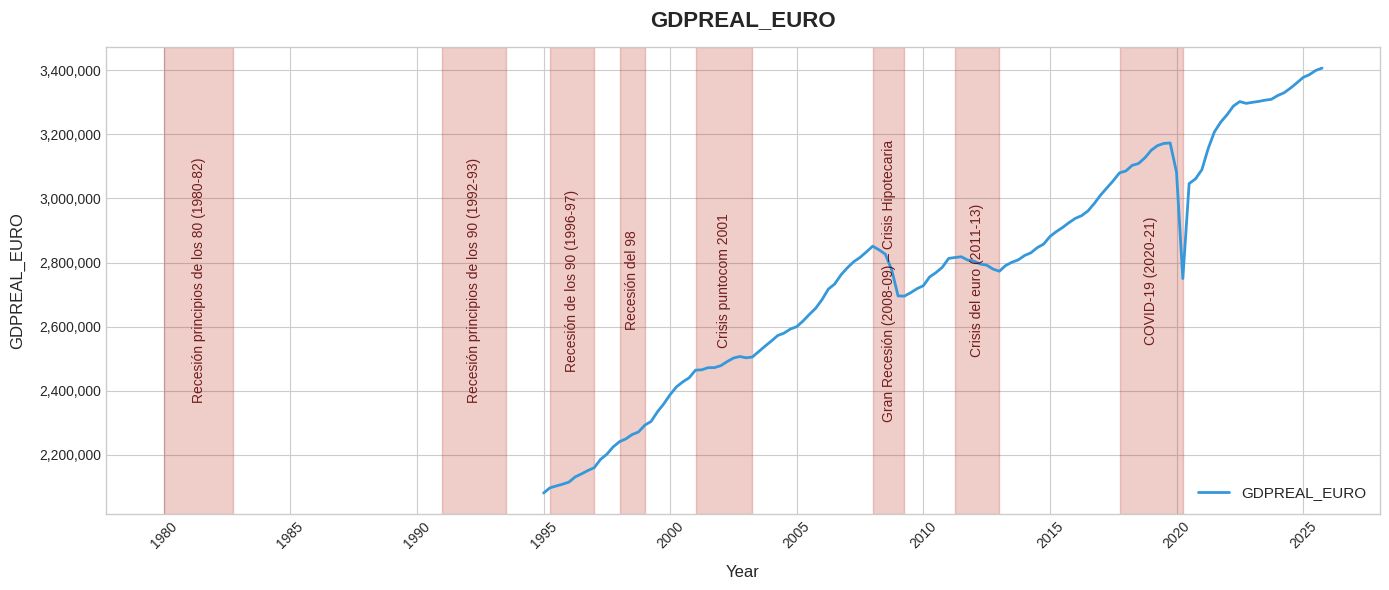

In [ ]:
fig,ax = plot_series(df_TODO,['GDPREAL_EEUU'])

# Gráfico EEUU

shade_recessions_with_labels(
    ax,
    df_TODO['RECESION_EEUU'],
    labels_recesiones_EEUU,
    color='#c0392b',
    alpha=0.25
)

# Grafico EURO
fig,ax = plot_series(df_TODO,['GDPREAL_EURO'])
shade_recessions_with_labels(
    ax,
    df_TODO['RECESION_EURO'],
    labels_recesiones_Europa,
    color='#c0392b',
    alpha=0.25
)

Aquí se puede observar cómo, durante los periodos de recesión, ha habido caídas muy significativas del GDP en Estados Unidos y Europa (lo cual es muy plausible). Este gráfico nos ayuda a conocer, de manera general, cómo se ha comportado el GDP con ambas recesiones pero, surgen las siguientes preguntas:

¿Cuánto decrece el GDP en cada una de las crisis?

¿Cuál ha sido la mayor caída del GDP?

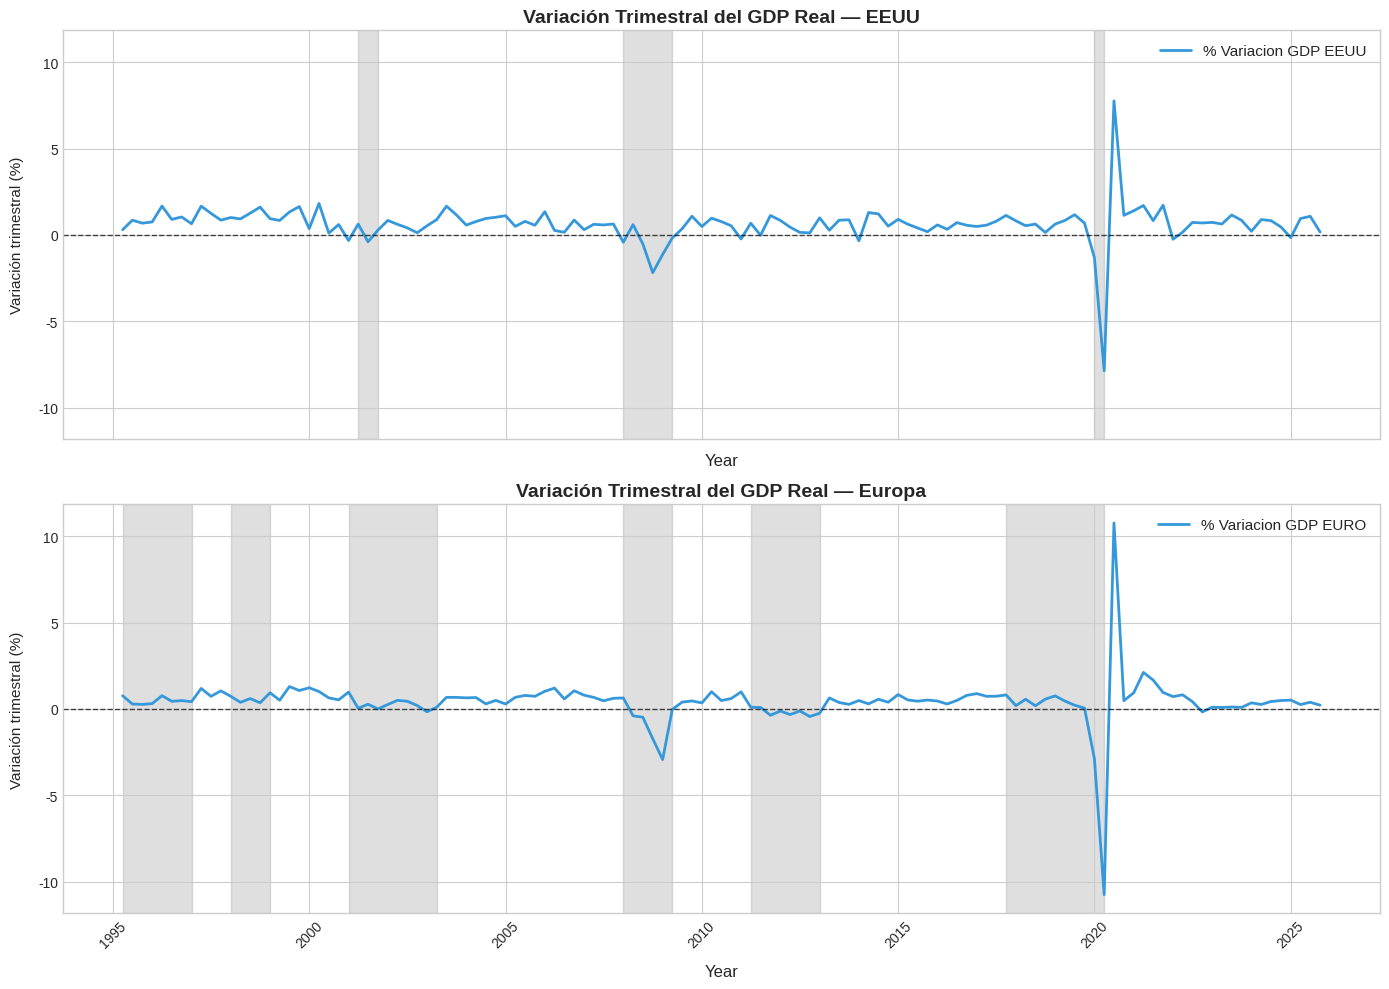

In [ ]:

df_clean = df_TODO[['GDPREAL_EEUU', 'GDPREAL_EURO']].dropna()
df_yoy   = df_clean.pct_change() * 100

df_yoy.rename(columns={
    'GDPREAL_EEUU': '% Variacion GDP EEUU',
    'GDPREAL_EURO': '% Variacion GDP EURO',
}, inplace=True)


fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,sharey = True)

_, ax1 = plot_series(df_yoy[['% Variacion GDP EEUU']],['% Variacion GDP EEUU'], ax=axes[0])
shade_recessions(ax1, df_TODO['RECESION_EEUU'].reindex(df_clean.index))
ax1.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)
ax1.set_title('Variación Trimestral del GDP Real — EEUU', fontsize=14, fontweight='bold')
ax1.set_ylabel('Variación trimestral (%)', fontsize=11)

_, ax2 = plot_series(df_yoy[['% Variacion GDP EURO']],['% Variacion GDP EURO'], ax=axes[1])
shade_recessions(ax2, df_TODO['RECESION_EURO'].reindex(df_clean.index))
ax2.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)
ax2.set_title('Variación Trimestral del GDP Real — Europa', fontsize=14, fontweight='bold')
ax2.set_ylabel('Variación trimestral (%)', fontsize=11)

plt.tight_layout()
plt.show()

Aquí se puede observar que la caída del GDP más importante fue en la crisis de 2020 (crisis del COVID). También se puede ver que el aumento más grande del GDP fue posterior a esta crisis, pues se recuperó la economía en los meses posteriores.

In [ ]:
def get_recession_periods(recession_series):
    periods = []
    in_recession = False
    start = None

    for date, val in recession_series.items():
        if val == 1 and not in_recession:
            in_recession = True
            start = date
        elif val != 1 and in_recession:
            in_recession = False
            periods.append((start, date))

    if in_recession:
        periods.append((start, recession_series.index[-1]))

    return periods


def calcular_caidas(periodos, pib_series, ventana_pre=4):
    resultados = []

    for inicio, fin in periodos:
        idx_inicio = pib_series.index.get_loc(inicio)
        idx_desde  = max(0, idx_inicio - ventana_pre)

        pico     = pib_series.iloc[idx_desde : idx_inicio + 1].max()
        segmento = pib_series.loc[inicio:fin]
        valle    = (segmento.iloc[:-1] if len(segmento) > 1 else segmento).min()

        resultados.append({
            'Inicio':    inicio,
            'Fin':       fin,
            'Pico':      round(pico, 1),
            'Valle':     round(valle, 1),
            'Caída (%)': round((valle - pico) / pico * 100, 2),
        })

    return pd.DataFrame(resultados)


# == Datos y cálculo
df_eeuu = df_TODO[['GDPREAL_EEUU', 'RECESION_EEUU']].dropna()
df_euro = df_TODO[['GDPREAL_EURO', 'RECESION_EURO']].dropna()

df_caidas_eeuu = calcular_caidas(get_recession_periods(df_eeuu['RECESION_EEUU']), df_eeuu['GDPREAL_EEUU'])
df_caidas_euro = calcular_caidas(get_recession_periods(df_euro['RECESION_EURO']),  df_euro['GDPREAL_EURO'])

print(df_caidas_eeuu[['Inicio', 'Fin', 'Pico', 'Valle', 'Caída (%)']].to_string(index=False))
print(df_caidas_euro[['Inicio', 'Fin', 'Pico', 'Valle', 'Caída (%)']].to_string(index=False))

    Inicio        Fin       Pico      Valle  Caída (%)
1980-01-01 1980-10-01  7341557.0  7181743.0      -2.18
1981-07-01 1983-01-01  7492405.0  7295631.0      -2.63
1990-07-01 1991-04-01 10090569.0  9951916.0      -1.37
2001-04-01 2002-01-01 14271694.0 14214516.0      -0.40
2008-01-01 2009-07-01 16915191.0 16269145.0      -3.82
2020-01-01 2020-07-01 20985448.0 19077992.0      -9.09
    Inicio        Fin      Pico     Valle  Caída (%)
1995-04-01 1997-04-01 2097397.9 2097397.9       0.00
1998-01-01 1999-04-01 2241598.3 2241598.3       0.00
2001-01-01 2003-07-01 2464601.9 2464601.9       0.00
2008-01-01 2009-07-01 2851156.2 2695367.5      -5.46
2011-04-01 2013-04-01 2815794.0 2772950.0      -1.52
2017-10-01 2020-07-01 3079815.2 2750166.8     -10.70


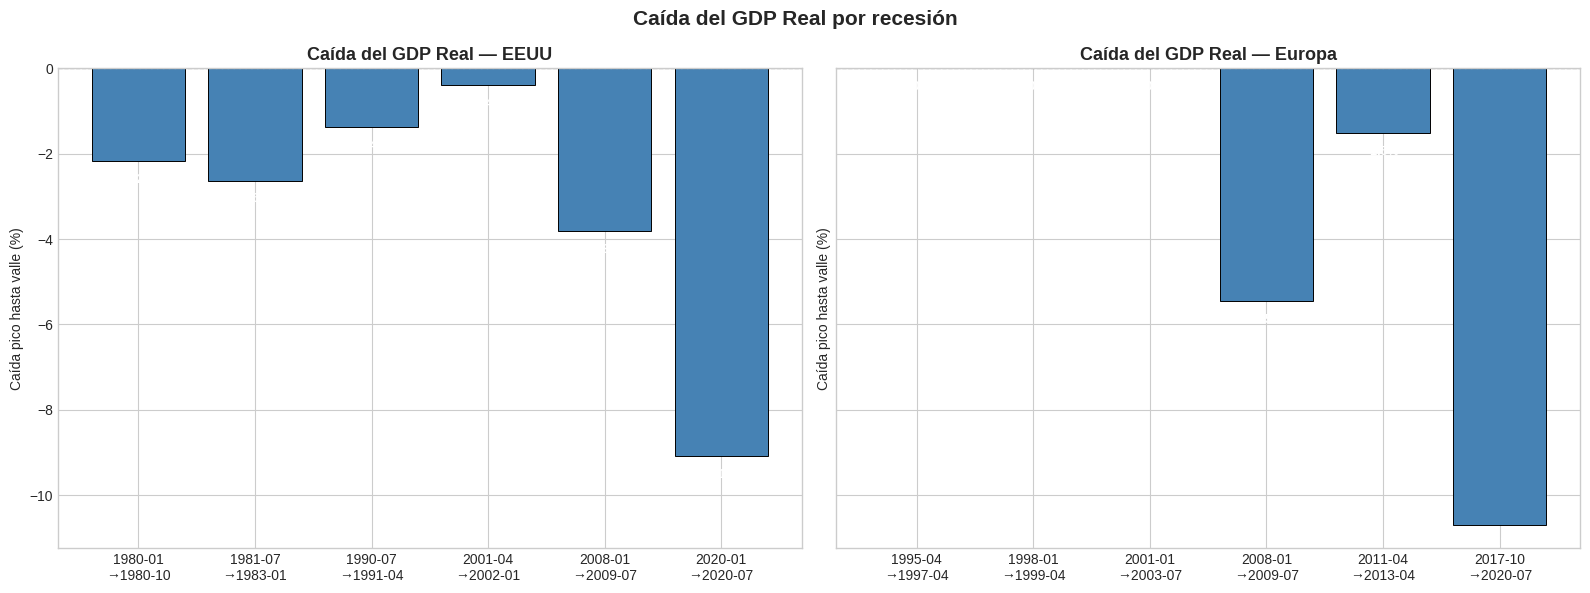

In [ ]:
# == Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, df, titulo in [
    (axes[0], df_caidas_eeuu, 'Caída del GDP Real — EEUU'),
    (axes[1], df_caidas_euro, 'Caída del GDP Real — Europa'),
]:
    labels = [f"{r['Inicio'].strftime('%Y-%m')}\n→{r['Fin'].strftime('%Y-%m')}" for _, r in df.iterrows()]
    ax.bar(labels, df['Caída (%)'], color='steelblue', edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel('Caída pico hasta valle (%)', fontsize=10)
    for i, val in enumerate(df['Caída (%)']):
        ax.text(i, val - 0.3, f'{val:.1f}%', ha='center', va='top', fontsize=9, fontweight='bold', color='white')

plt.suptitle('Caída del GDP Real por recesión', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Aquí se puede observar que el GDP de las dos economías estuvo muy perjudicado por la crisis del COVID, presentando una caída del 9% en el caso de EEUU y del 11% en el caso de Europa.

Particularmente, en el caso de Europa fue más significativo, pues venía de un periodo de recesión económica desde enero de 2018.

### **4.3. Comparación de la producción industrial**

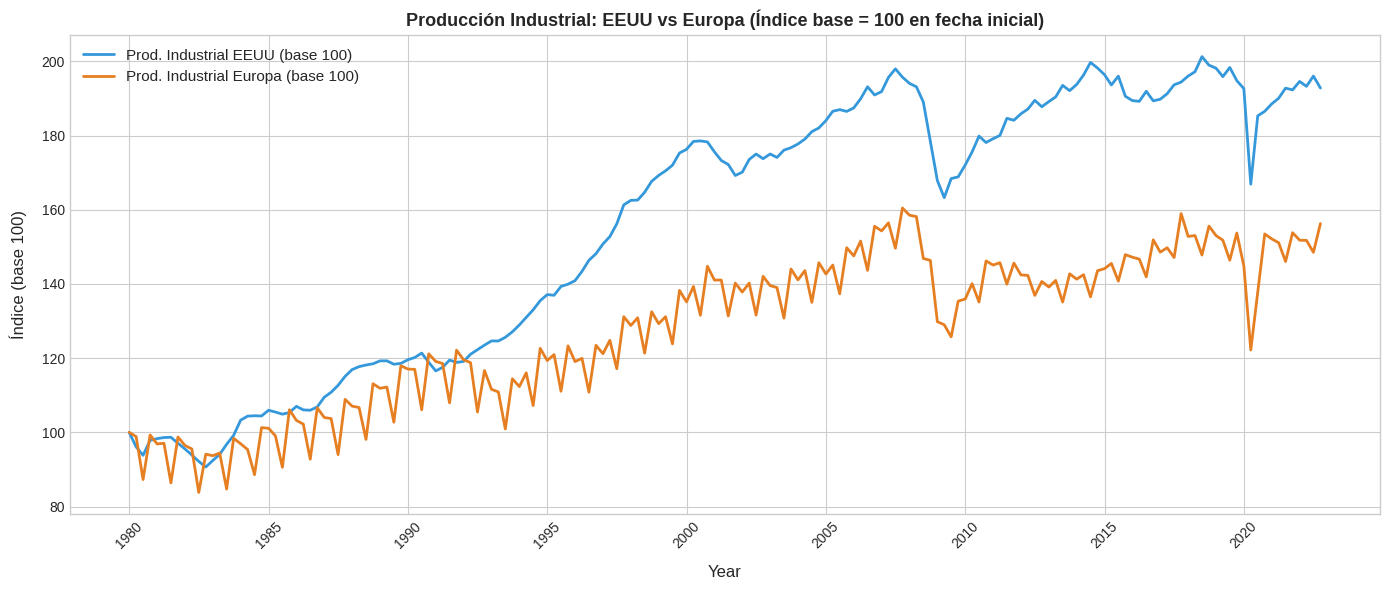

In [ ]:
# Producción industrial indexada a 100 en la primera fecha común
df_ind = df_TODO[['INDUSTRIAL_PRODUCTION_EEUU', 'INDUSTRIAL_PRODUCTION_EURO']].dropna()

base_eeuu = df_ind['INDUSTRIAL_PRODUCTION_EEUU'].iloc[0]
base_euro = df_ind['INDUSTRIAL_PRODUCTION_EURO'].iloc[0]

# Ajuste a 1980 como el 100
df_ind_idx = pd.DataFrame({
    'Prod. Industrial EEUU (base 100)': df_ind['INDUSTRIAL_PRODUCTION_EEUU'] / base_eeuu * 100,
    'Prod. Industrial Europa (base 100)': df_ind['INDUSTRIAL_PRODUCTION_EURO'] / base_euro * 100,
})

fig, ax = plot_series(df_ind_idx, list(df_ind_idx.columns))

ax.set_title('Producción Industrial: EEUU vs Europa (Índice base = 100 en fecha inicial)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Índice (base 100)')
plt.tight_layout()
plt.show()


Por un lado, podemos observar que la producción industrial europea en este índice se rige por una estacionalidad que la americana no tiene tan pronunciado.

Por otro lado, podemos observar que la producción industrial americana se distanció mucho entre 1993 - 2000, mayormente debido a nuevas tecnologías de la información (computadoras e internet) que dispararon la productividad y, junto a
la burbuja PuntoCom, generó capital e importantes nuevos empleos.

En cuanto a las crisis acontecidas en esos periodos, podemos ver claramente dos crisis que afectaron a ambas economías: la crisis de 2008 y la crisis del Covid. Sin embargo, la crisis de PuntoCom afectó no muy drásticamente a la producción estadounidense y la europea no se vió afectada.

También podemos observar que, a partir de los picos de 2008, la producción industrial no ha aumentado, sino que se ha mantenido en niveles estables desde ese momento.



### **4.4 Comparación de empleo**

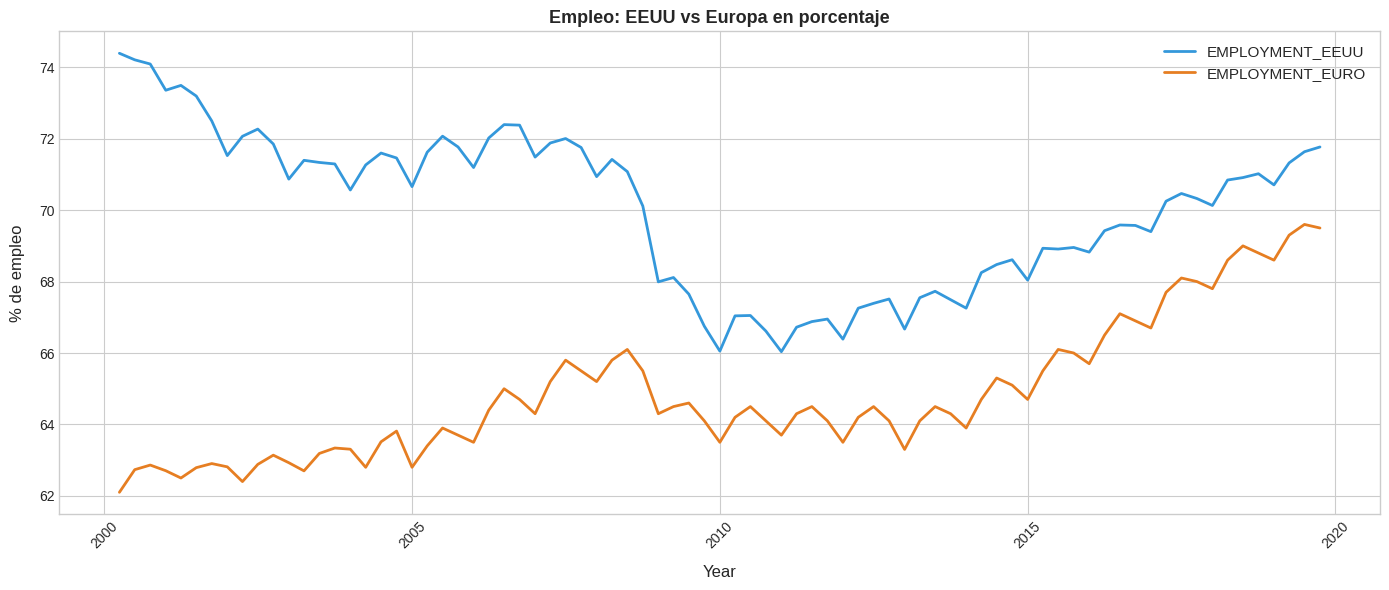

In [ ]:
# Empleo indexado a 100 en la primera fecha común. Año 2000
df_emp = df_TODO[['EMPLOYMENT_EEUU', 'EMPLOYMENT_EURO']].dropna()

fig, ax = plot_series(df_emp, list(df_emp.columns))
ax.set_title('Empleo: EEUU vs Europa en porcentaje',fontsize=13, fontweight='bold')
ax.set_ylabel('% de empleo')
plt.tight_layout()
plt.show()

En esta comparación del empleo entre Estados Unidos y Europa, podemos ver cómo existe una estacionalidad en ambas series.

Otro hecho destacable es la importante caída del porcentaje de población empleada en Estados Unidos en 2008 desde un 71% hasta un 66% en 2010. Esta caída tan brusca no se da en Europa.

Cabe decir también que la notable diferencia que había en el 2000 de 12 puntos porcentuales se ha ido reduciendo hasta 2020 con apenas 2 puntos porcentuales de diferencia.

### **4.5. Comparación de precios de la vivienda**

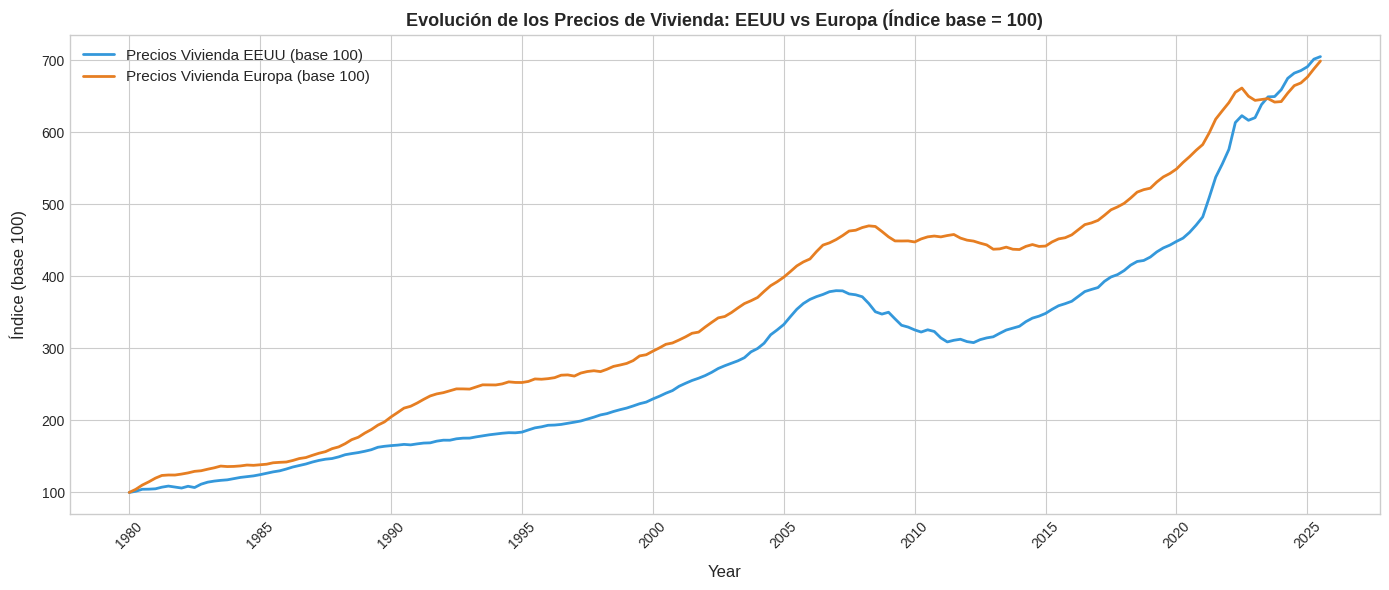

In [ ]:
# Precios de vivienda indexados a 100 en la fecha inicial común
df_hous = df_TODO[['HOUSING_PRICE_INDEX_EEUU', 'HOUSING_PRICE_INDEX_EURO']].dropna()

base_eeuu_h = df_hous['HOUSING_PRICE_INDEX_EEUU'].iloc[0]
base_euro_h = df_hous['HOUSING_PRICE_INDEX_EURO'].iloc[0]

# Ajuste a la primera fecha
df_hous_idx = pd.DataFrame({
    'Precios Vivienda EEUU (base 100)': df_hous['HOUSING_PRICE_INDEX_EEUU'] / base_eeuu_h * 100,
    'Precios Vivienda Europa (base 100)': df_hous['HOUSING_PRICE_INDEX_EURO'] / base_euro_h * 100,
})

fig, ax = plot_series(df_hous_idx, list(df_hous_idx.columns))
ax.set_title('Evolución de los Precios de Vivienda: EEUU vs Europa (Índice base = 100)',fontsize=13, fontweight='bold')
ax.set_ylabel('Índice (base 100)')
plt.tight_layout()
plt.show()

Aquí podemos observar cómo el precio de una vivienda ha ido evolucionando de manera muy similar a lo largo del tiempo.

Podemos ver que ambos índices en la crisis de la vivienda del 2008 decrecieron. A pesar de ese bajón, en general, el precio de la vivienda ha seguido una tendencia al alza durante todo este tiempo.

Tanto en EEUU como en Europa, el precio de las viviendas se han multiplicado por 7. Sin embargo, el GDP en EEUU solo ha crecido en un 300% (desde 1980), mientras que en Europa el crecimiento ha sido de apenas un 200% (desde 1995).

Esto, junto con el apartado 4.3 donde podemos ver que la producción industrial es de apenas el doble en ese mismo rango de fechas, ayuda a extraer las siguientes conclusiones:

1. El precio de la vivienda ha crecido muy por encima de la riqueza real generada por la economía (GDP).

2. Esto significa que las viviendas se han encarecido, no porque la economía sea más productiva, sino por otros factores artificiales.

Es decir, de manera global, el precio de las viviendas se ha encarecido mucho en comparación con el salario.



### **4.6. Comparación de exportaciones e importaciones.**

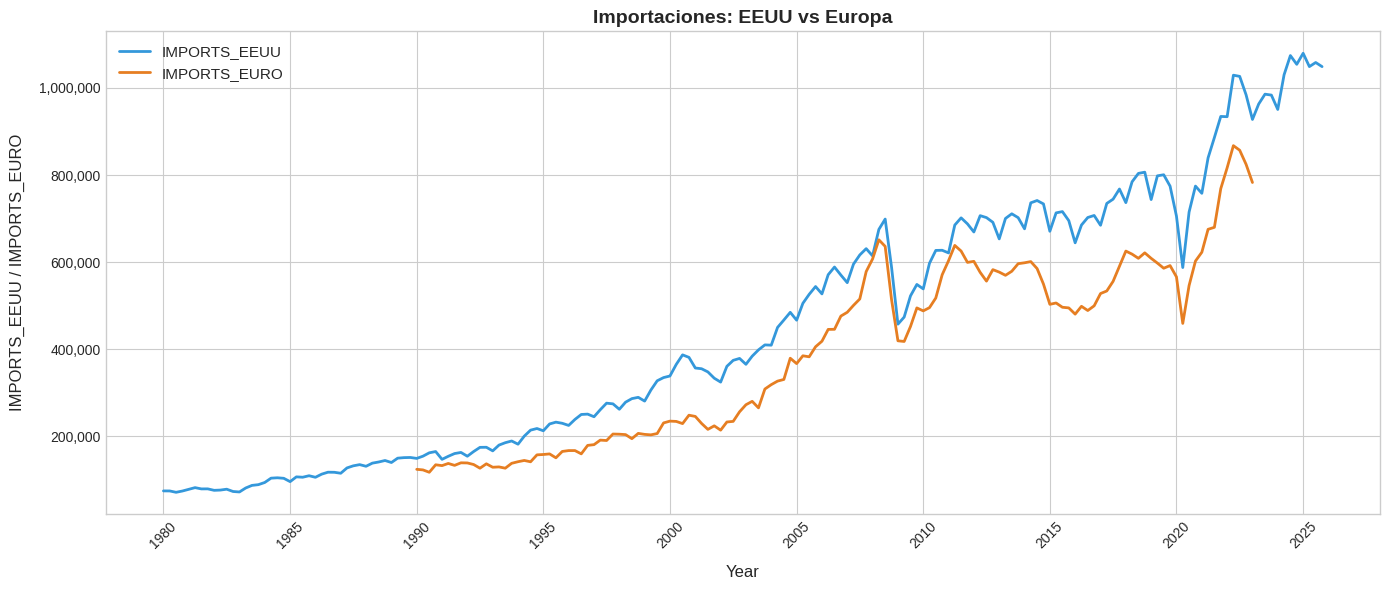

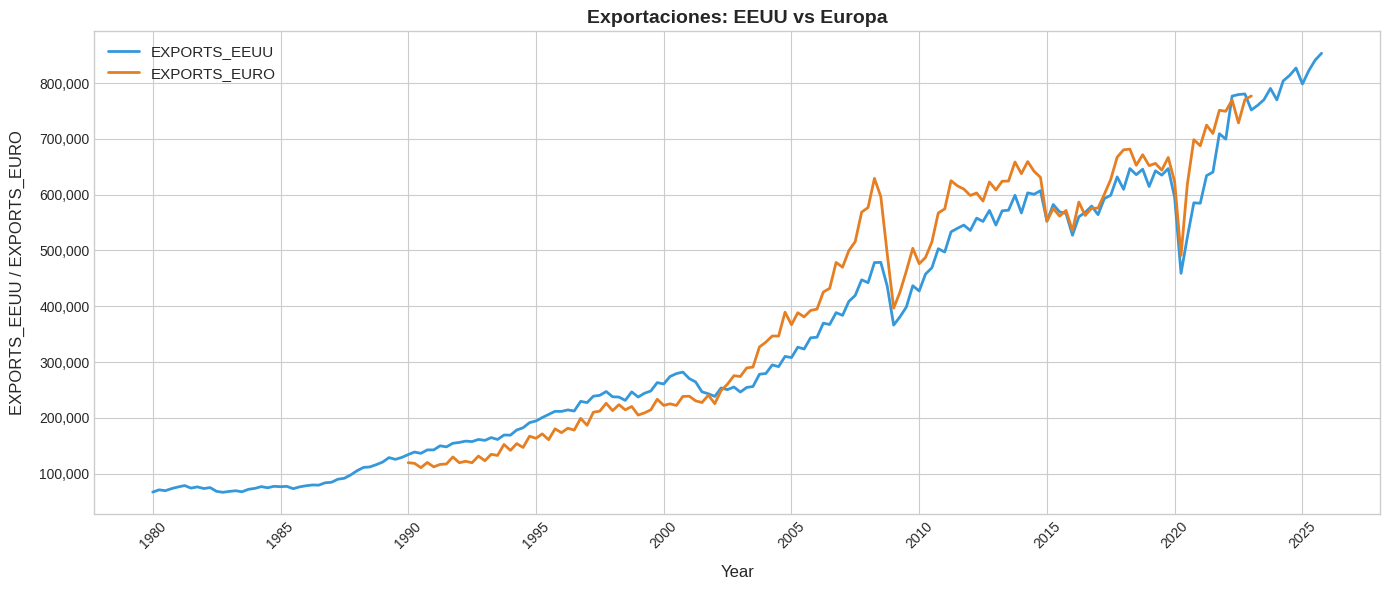

In [ ]:

# =====================
# Comparación cruzada: Importaciones EEUU vs Europa
# =====================
fig, ax = plt.subplots(figsize=(14, 6))
plot_series(df_TODO, ['IMPORTS_EEUU', 'IMPORTS_EURO'], ax=ax)
ax.set_title('Importaciones: EEUU vs Europa', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# =====================
# Comparación cruzada: Exportaciones EEUU vs Europa
# =====================
fig, ax = plt.subplots(figsize=(14, 6))
plot_series(df_TODO, ['EXPORTS_EEUU', 'EXPORTS_EURO'], ax=ax)
ax.set_title('Exportaciones: EEUU vs Europa', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

Observamos que EEUU ha hecho más importaciones que Europa mientras que, en cuanto a las exportaciones, Europa ha estado por encima o la par que Estados Unidos. Además, Europa suele tener un superávit comercial al exportar más de lo que importa.



### **4.7. Comparación de la inflación**

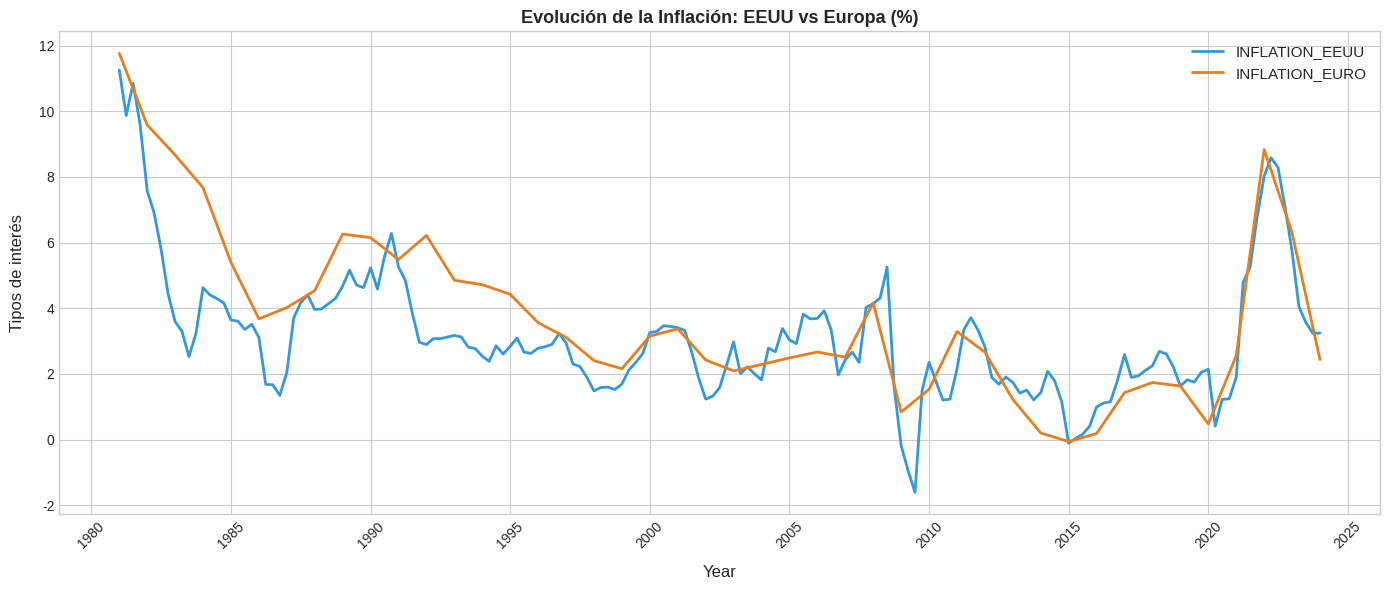

In [ ]:
df_infla = df_TODO[['INFLATION_EEUU', 'INFLATION_EURO']].dropna()

fig, ax = plot_series(df_infla, ['INFLATION_EEUU', 'INFLATION_EURO'])
ax.set_title('Evolución de la Inflación: EEUU vs Europa (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Tipos de interés')
plt.tight_layout()
plt.show()

En 1980, se observa que la inflación en ambas economías alcanzó máximos históricos. Desde ese momento y hasta antes de 2002, la inflación en EEUU era mayor que en Europa. A partir de ese momento, han ido a la par. Además, en 2008 se observa que la inflación en Estados Unidos alcanzó mínimos históricos, consecuencia de la crisis que se produjo en ese año. Pasado 2020, ambas economías experimentaron una subida drástica de la inflación por la crisis del Covid.

/tmp/ipykernel_726/1391498958.py:231: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'INFLATION_EEUU vs INFLATION_EURO'}, ylabel='Valores'>)

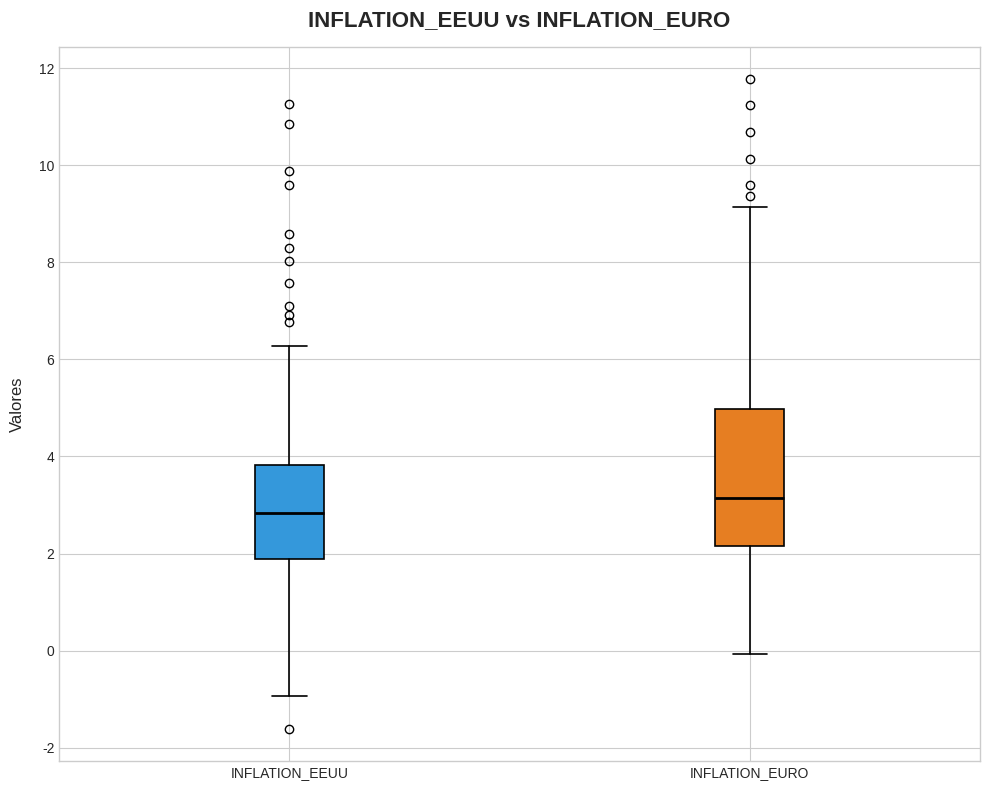

In [ ]:
plot_boxplots(df_infla, ['INFLATION_EEUU', 'INFLATION_EURO'])

Otro aspecto interesante a analizar la inflación es su variabilidad a lo largo de los años. En EEUU, es posible ver que la inflación se ha mantenido centrada generalmente en el 3% y ha variado entre el 2% y 4%. En el caso de Europa, la inflación se concentra cerca del 3.2% y alcanza valores entre 5.5% y 2.2%, mostrando una mayor variabilidad que Estados Unidos.

Sin embargo, en ambas economías podemos apreciar que ha habido situaciones en las que la inflación ha alcanzado valores alejados de la tendencia central de este indicador. Comparando estos casos extremos con la evolución temporal de la inflación, vemos que suelen coincidir con periodos de crisis.

### **4.8. Comparación de los tipos de interés**

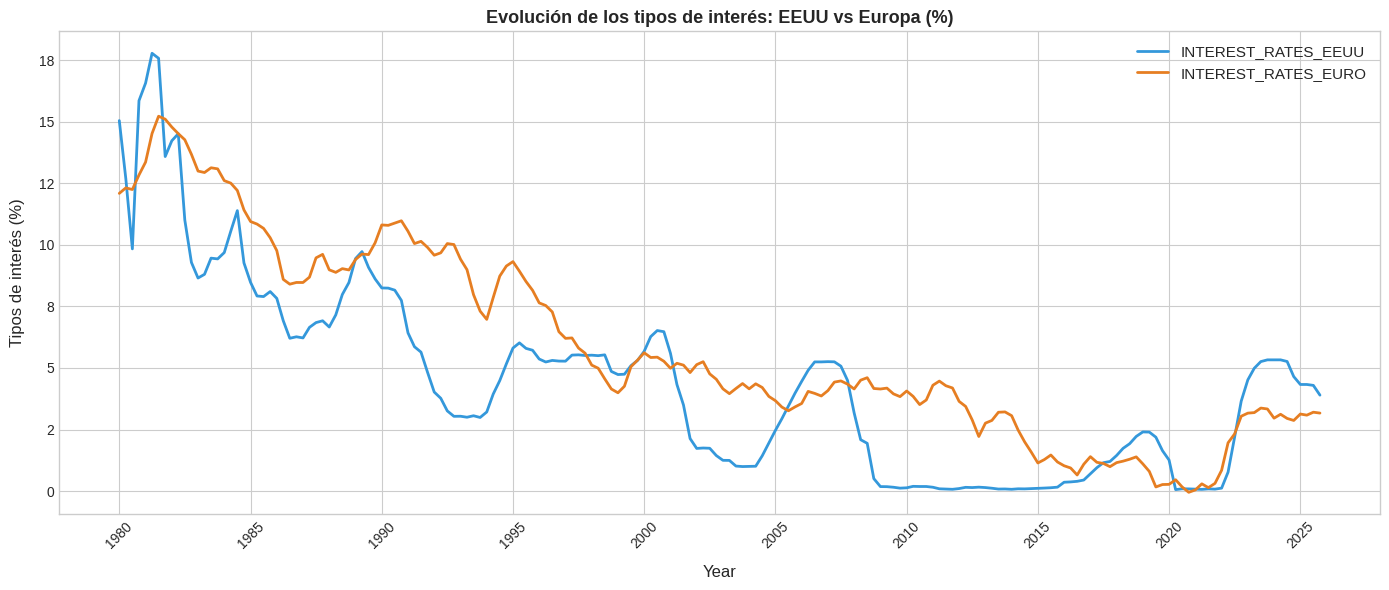

In [ ]:
df_tipo_int = df_TODO[['INTEREST_RATES_EEUU', 'INTEREST_RATES_EURO']].dropna()

fig, ax = plot_series(df_tipo_int, ['INTEREST_RATES_EEUU', 'INTEREST_RATES_EURO'])
ax.set_title('Evolución de los tipos de interés: EEUU vs Europa (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Tipos de interés (%)')
plt.tight_layout()
plt.show()

En 1981, ambas economías sufrieron una subida de los tipos de interés por la crisis de esta época, siendo esta mucho más pronunciada en el caso de EEUU. Desde entonces, los tipos de interés han experimentado una tendencia a la baja hasta antes de la crisis del Covid. En Estados Unidos, los tipos de interés han sufrido bajadas y subidas más drásticas, mientras que en Europa han disminuido más gradualmente. Además, a partir de la crisis de 2008, los tipos de interés estadounidenses se aproximan a valores cercanos al 0% a causa de aliviar los efectos de la crisis de estos años. Finalmente, tras la crisis del Covid, los tipos de interés de ambas economías han experimentado un repunte, siendo este mayor en EEUU.


/tmp/ipykernel_726/1391498958.py:231: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


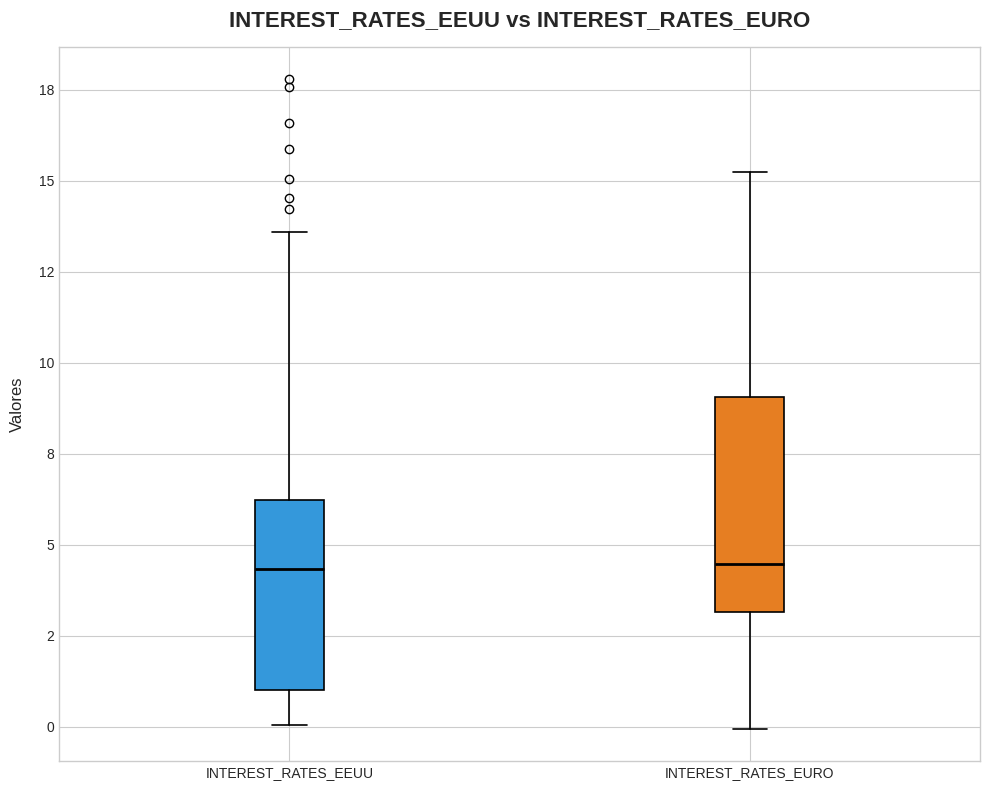

In [ ]:
plot_boxplots(df_tipo_int, ['INTEREST_RATES_EEUU', 'INTEREST_RATES_EURO'])
plt.tight_layout()
plt.show()

Analizando las distribuciones de los tipos de interés, el IQR de los boxplots es similar, lo que indica que los intereses han tenido la misma variabilidad a lo largo del tiempo. Aun así, puede observarse que, en general, los tipos de interés de EEUU han sido menores del 7 %, mientras que en Europa se han mantenido por debajo del 9 %. Además, en EEUU se observan valores atípicos, lo que refleja que, en determinados momentos, los tipos de interés fueron significativamente mayores que en el resto de la distribución (por ejemplo, durante los máximos de 1981 comentados anteriormente).



##  **5. Predicción del GDP**
---

En este apartado, haremos una breve vista a la predicción de algunos de los indicadores económicos de EEUU y Europa.

El modelo elegido para hacer estas predicciones ha sido el modelo ARIMA. Con este modelo vamos a intentar predecir los valores de ciertos indicadores un año vista.

In [ ]:
serie_GDP_EEUU = df_TODO['GDPREAL_EEUU'].dropna().copy()
serie_GDP_EURO = df_TODO['GDPREAL_EURO'].dropna().copy()

In [ ]:

modelo_EEUU = auto_arima(
    serie_GDP_EEUU,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=5,
    max_q=5,
    max_P=5,
    max_Q=5,
    seasonal=False,
    trace=True,
    stepwise=True
)

modelo_EURO = auto_arima(
    serie_GDP_EURO,
    start_p=0,
    start_q=0,
    start_P=0,
    start_Q=0,
    max_p=5,
    max_q=5,
    max_P=5,
    max_Q=5,
    seasonal=False,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4970.836, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4969.582, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4969.681, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5007.140, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=4971.491, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4971.570, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=4972.497, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=5009.013, Time=0.04 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.713 seconds
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2982.998, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2985.099, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2985.190, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2988.178, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=298

Al coger como mejor modelo ARIMA en la serie EEUU el modelo con p=1, q=1, r=0, se puede decir que la serie del GDP estadounidense se modela mejor con una estructura autorregresiva, demostrando mayor estabilidad y dependencia de valores pasados.

También, al ser el mejor modelo ARIMA de la serie europea el modelo con p=r=0, q=1, se observa que la  serie del GDP europeo parece mucho más constante, lo cual puede deberse tanto a mayor inestabilidad económica como a tener menos datos históricos.

Una vez hemos ajustado los modelos de predicción vamos a intentar predecir el GDP un año vista y el rango de valores del GDP que engloba el 95% de la predicción.

In [ ]:
pred_EEUU, confint_EEUU = modelo_EEUU.predict(
    n_periods=4, return_conf_int=True, alpha=0.05)

pred_EURO,confint_EURO = modelo_EURO.predict(
    n_periods=4, return_conf_int=True, alpha=0.05)



/tmp/ipykernel_726/1290189971.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  pred_index_EEUU = pd.date_range(serie_GDP_EEUU.index[-1], periods=len(pred_EEUU)+1, freq='Q')[1:]


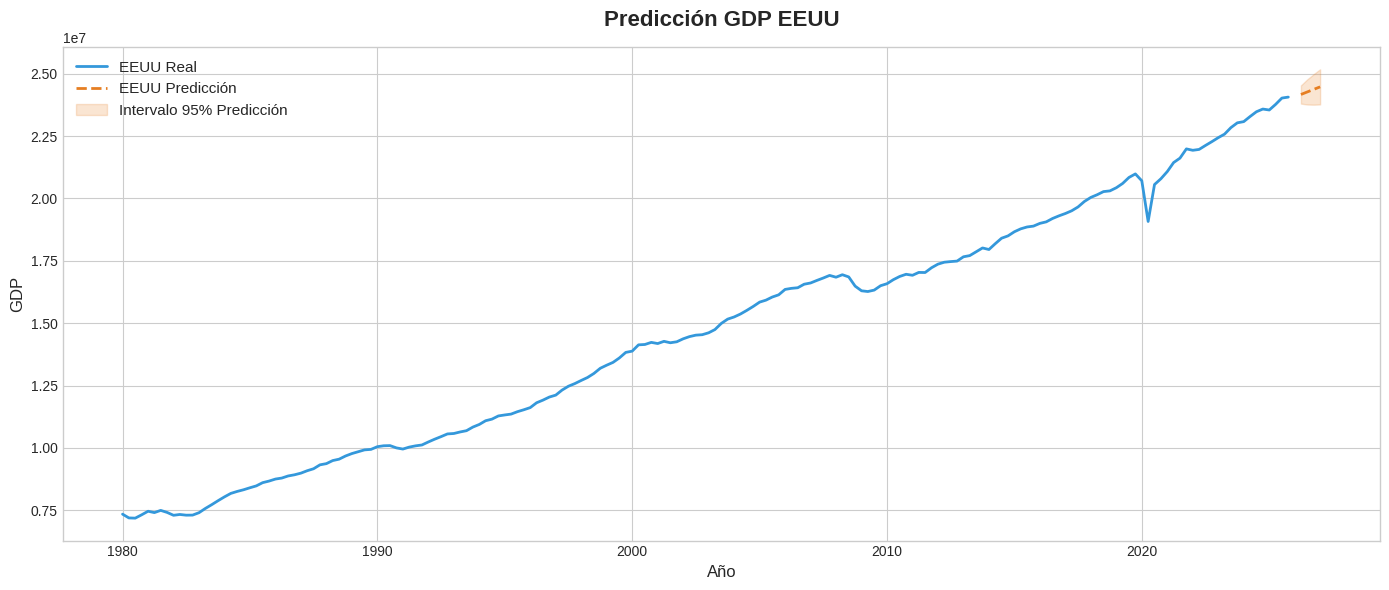

In [ ]:
pred_index_EEUU = pd.date_range(serie_GDP_EEUU.index[-1], periods=len(pred_EEUU)+1, freq='Q')[1:]

fig, ax = plt.subplots(figsize=(14, 6))

# Valores reales
ax.plot(serie_GDP_EEUU.index, serie_GDP_EEUU, color='#3498db', label='EEUU Real', linewidth=2)

# Predicción
ax.plot(pred_index_EEUU, pred_EEUU, color='#e67e22', label='EEUU Predicción', linewidth=2, linestyle='--')

# Sombreado
ax.fill_between(
    pred_index_EEUU,
    confint_EEUU[:, 0],
    confint_EEUU[:, 1],
    color='#e67e22',
    alpha=0.2,
    label='Intervalo 95% Predicción'
)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('GDP', fontsize=12)

ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')
plt.title('Predicción GDP EEUU', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_726/3744355044.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  pred_index_EURO = pd.date_range(serie_GDP_EURO.index[-1], periods=len(pred_EURO)+1, freq='Q')[1:]


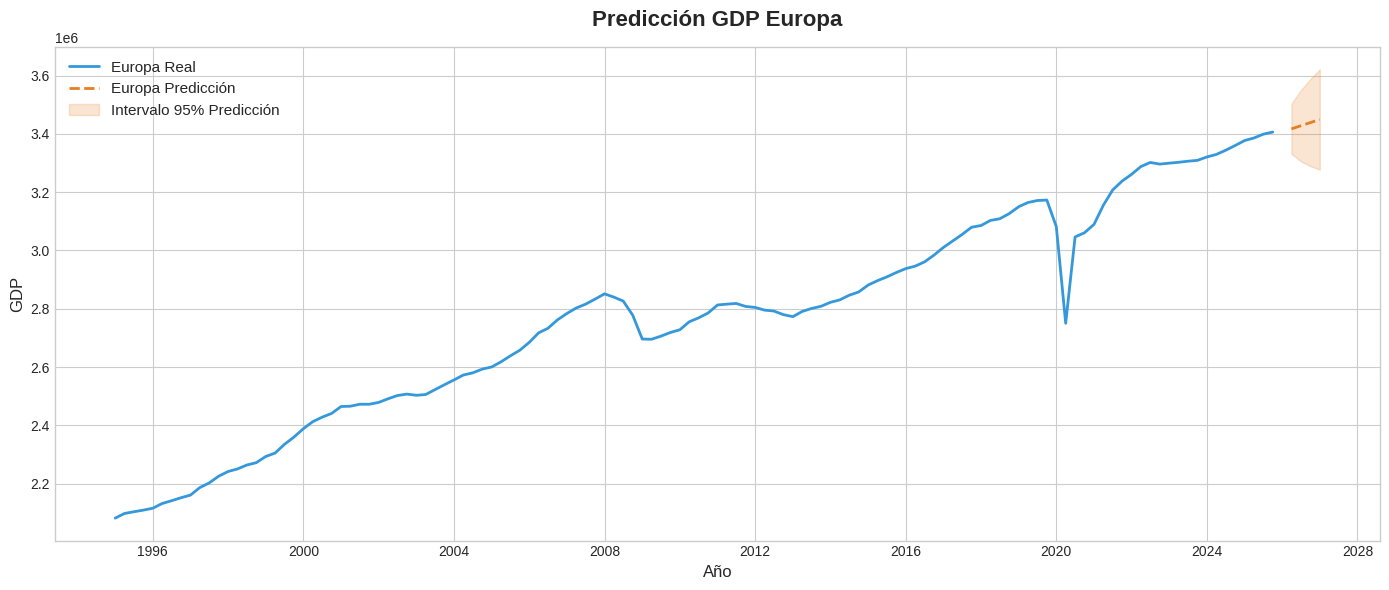

In [ ]:
pred_index_EURO = pd.date_range(serie_GDP_EURO.index[-1], periods=len(pred_EURO)+1, freq='Q')[1:]

fig, ax = plt.subplots(figsize=(14, 6))

# Valores reales
ax.plot(serie_GDP_EURO.index, serie_GDP_EURO, color='#3498db', label='Europa Real', linewidth=2)

# Predicción
ax.plot(pred_index_EURO, pred_EURO, color='#e67e22', label='Europa Predicción', linewidth=2, linestyle='--')

# Sombreado
ax.fill_between(
    pred_index_EURO,
    confint_EURO[:, 0],
    confint_EURO[:, 1],
    color='#e67e22',
    alpha=0.2,
    label='Intervalo 95% Predicción'
)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('GDP', fontsize=12)

ax.legend(fontsize=11, framealpha=0.9, edgecolor='lightgrey')
plt.title('Predicción GDP Europa', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# EEUU
widths_eeuu = confint_EEUU[:, 1] - confint_EEUU[:, 0]
percent_widths_eeuu = np.abs(widths_eeuu) / np.abs(pred_EEUU) * 100
media_eeuu = np.mean(percent_widths_eeuu)

# EURO
widths_euro = confint_EURO[:, 1] - confint_EURO[:, 0]
percent_widths_euro = np.abs(widths_euro) / np.abs(pred_EURO) * 100
media_euro = np.mean(percent_widths_euro)

print(f'EEUU: Ancho promedio del intervalo (porcentual): {media_eeuu:.2f}%')
print(f'EURO: Ancho promedio del intervalo (porcentual): {media_euro:.2f}%')

EEUU: Ancho promedio del intervalo (porcentual): 4.49%
EURO: Ancho promedio del intervalo (porcentual): 7.70%


Al comparar las predicciones de GDP entre Europa y EEUU utilizando modelos ARIMA, se observa que la economía europea presenta una mayor inestabilidad. Esto se refleja en el intervalo de confianza, donde la varianza porcentual de la predicción europea es aproximadamente el doble que la de la predicción estadounidense. Es decir, el ancho relativo de la banda de predicción para Europa, medido como porcentaje respecto al valor predicho, es significativamente mayor. Esta mayor varianza indica una incertidumbre superior en las estimaciones de GDP europeo.

Además, esta incertidumbre es agravada por la menor cantidad de datos disponibles para Europa respecto a EEUU. Tener valores históricos del GDP desde 1995 limita la capacidad del modelo ARIMA para captar la dinámica temporal y ajustar adecuadamente sus parámetros.

## **6. Uso de IA generativa**
---

La IA generativa se ha usado para las siguientes tareas:

1. **Revisión de faltas de ortografía y erratas en los textos**: "Voy a pasarte textos y quiero que revises si hay erratas o faltas de ortografía. No quiero que modifiques nada."

2. **Generación del gráfico de los coeficientes de simetría**: "Quiero hacer un gráfico de barras en el que las variables de una misma categoría económica estén juntas entre sí pero separadas de otras categorías. Quiero que aparezca de un color las variables de EEUU y de otro las de Europa. Además, tienen que aparecer dos líneas discontinuas en -0.5 y 0.5."

3. **Generación de funciones de plot**: Se ha utilizado para la creación de funciones de plots incluidos en el util de plots del apartado 1.2.

